In [3]:
#Carga de paquetes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import time
from scipy.stats import pointbiserialr
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.experimental import enable_iterative_imputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder 
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import lime 
import lime.lime_tabular

# Introducción
El análisis de riesgo crediticio es un aspecto fundamental para las plataformas de préstamos en línea, ya que permite evaluar la probabilidad de que un prestatario incumpla con sus obligaciones financieras. En este contexto, la plataforma Lending Club ofrece un conjunto amplio de datos históricos sobre préstamos otorgados, incluyendo información financiera, demográfica y crediticia de los solicitantes. El análisis de estos datos permite identificar patrones y relaciones entre las características de los prestatarios y el resultado final del préstamo.

En este proyecto se busca construir un modelo de clasificación supervisada capaz de predecir si un préstamo emitido por Lending Club resultará en default (1) o será pagado completamente (0). Para ello, es necesario realizar previamente un Análisis Exploratorio de Datos (EDA) que permita comprender la estructura del conjunto de datos, identificar valores faltantes, detectar posibles inconsistencias y analizar la distribución de las variables más relevantes.

El EDA también permite examinar la relación entre las variables predictoras y la variable objetivo, lo cual facilita la selección de características relevantes y la preparación adecuada de los datos para el entrenamiento de modelos de aprendizaje automático. Posteriormente, se comparará el desempeño de los modelos implementados utilizando scikit-learn y PySpark, evaluando su capacidad predictiva y su eficiencia computacional. Finalmente, se empleará la técnica LIME (Local Interpretable Model-Agnostic Explanations) para interpretar las predicciones generadas por los modelos y comprender el impacto de las variables en las decisiones de clasificación.

# Objetivo

Construir un modelo de clasificación supervisada para predecir si un préstamo emitido por la plataforma Lending Club resultará en default (1) o será pagado completamente (0). El objetivo es comparar el desempeño de los modelos construidos con scikit-learn y PySpark, además de aplicar LIME para interpretar predicciones.

# Análisis Exploratorio de Datos

Inicialmente se procederá con el análisis del dataset y sus características, junto al estudio de las variables consideradas más relevantes para el desarrollo del modelo.

## Origen del dataset
Esta es una base de datos que contiene información sobre los créditos aceptados y rechazados dentro de la plataforma Lending Club, proveniente de su sitio Web. Como los datos de créditos aceptados y rechazados se encuentran en archivos distintos, se trabajará con el archivo de aceptados ya que se busca estudiar si el crédito fue pagado o entró en default.

- Fuente: Kaggle https://www.kaggle.com/datasets/wordsforthewise/lending-club

In [4]:
#Carga del dataset, se debe especificar que el archivo esta separado por ,
ruta = r"C:\Users\User\Desktop\MachineLearningUN\jbook_mini_proyecto\docs\accepted_2007_to_2018Q4.csv"
df =  pd.read_csv(ruta, sep = ",")

C:\Users\User\AppData\Local\Temp\ipykernel_9544\204528052.py:3: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  df =  pd.read_csv(ruta, sep = ",")


## Características del dataset
Comprobemos inicialmente las dimensiones de este dataset:

In [5]:
#Dimensiones del dataset
df.shape

(2260701, 151)

Se cuenta con una cantidad total de 2260701 entradas, cada una representando un préstamo aprobado, caracterizados por 151 variables. Luego de esto se observan las 5 primeras entradas para familiarizarse con la estructura del dataset:

In [6]:
#Primeros datos 
pd.options.display.max_rows = 1000
df.head().T

,0,1,2,3,4
id,68407277,68355089,68341763,66310712,68476807
member_id,NaN,NaN,NaN,NaN,NaN
loan_amnt,3600.0,24700.0,20000.0,35000.0,10400.0
funded_amnt,3600.0,24700.0,20000.0,35000.0,10400.0
funded_amnt_inv,3600.0,24700.0,20000.0,35000.0,10400.0
term,36 months,36 months,60 months,60 months,60 months
int_rate,13.99,11.99,10.78,14.85,22.45
installment,123.03,820.28,432.66,829.9,289.91
grade,C,C,B,C,F
sub_grade,C4,C1,B4,C5,F1


Se puede observar inicialmente que algunas variables se presentan como NaN para las 5 entradas, esto se analizará a profundidad más adelante. Luego de esto se procede con un descriptivo inicial de las variables:

In [7]:
#Descriptivo Inicial sin tratar el dataset
df.info(verbose=True, show_counts=True )

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Data columns (total 151 columns):
 #    Column                                      Non-Null Count    Dtype  
---   ------                                      --------------    -----  
 0    id                                          2260701 non-null  object 
 1    member_id                                   0 non-null        float64
 2    loan_amnt                                   2260668 non-null  float64
 3    funded_amnt                                 2260668 non-null  float64
 4    funded_amnt_inv                             2260668 non-null  float64
 5    term                                        2260668 non-null  object 
 6    int_rate                                    2260668 non-null  float64
 7    installment                                 2260668 non-null  float64
 8    grade                                       2260668 non-null  object 
 9    sub_grade                                   

In [8]:
import pandas as pd

#Variables numéricas
num_vars = df.select_dtypes(include=['int64', 'float64'])

#Variables categóricas
cat_vars = df.select_dtypes(include=['object', 'category'])

print("Número de variables numéricas:", num_vars.shape[1])
print("Número de variables categóricas:", cat_vars.shape[1])

Número de variables numéricas: 113
Número de variables categóricas: 38


Nuevamente confirmamos que se manejan 151 variables, de las cuáles 113 son númericas y 38 categóricas, además de esto se puede observar que muchas de estas variables poseen una gran cantidad de valores NaN, por lo tanto no están aportando al estudio, por consecuente, no están aportando al modelo. Para lidiar con esta situación se realizará un tratamiento para los valores NaN y para las variables que puedan llegar a afectar el modelo, de tal manera que se pueda asegurar la efectividad del mismo.

## Tratamiento de datos faltantes 

Inicialmente se analizará por cada variable el número de NaN y el porcentaje que representan en el total de los datos:

In [9]:
#Valores Faltantes
missing = df.isna().sum().to_frame("NaN")
missing["Porcentaje"] = (missing["NaN"] / len(df)) * 100
missing

,NaN,Porcentaje
id,0,0.000000
member_id,2260701,100.000000
loan_amnt,33,0.001460
funded_amnt,33,0.001460
funded_amnt_inv,33,0.001460
term,33,0.001460
int_rate,33,0.001460
installment,33,0.001460
grade,33,0.001460
sub_grade,33,0.001460


Se observa que existen una considerable cantidad de variables con un gran porcentaje de valores NaN, en casos con un gran porcentaje no vale la pena imputar ya que se terminaría afectando la distribución y en consecuencia la calidad del modelo, por tanto utilizando un porcentaje de 20% de NaN como línea de corte, se eliminarán las variables que superen este porcentaje y se imputarán las variables restantes:

In [10]:
#Eliminar variables que tengan un porcentaje de NaN mayor al 20%
cols_eliminar = missing[missing["Porcentaje"] > 20].index.tolist()
df = df.drop(columns=cols_eliminar)

Para la imputación de la variable "earliest_cr_line" que indica la fecha en la cuál el cliente realizó su primer crédito, se hará imputación aleatoria para no alterar la distribución, ya que al ser una fecha la frecuencia de la moda es bastante pequeña:

In [11]:
#Imputación de de earliest cr line
missing = df["earliest_cr_line"].isna()

df.loc[missing, "earliest_cr_line"] = np.random.choice(
    df["earliest_cr_line"].dropna(),
    size=missing.sum()
)

df["dti"] = df["dti"].replace([-1, 999], np.nan)

Luego de esto el resto de variables categóricas se imputan con la moda y las variables númericas con la mediana:

In [12]:
#Se imputan las demás
categoricas = df.select_dtypes(include="object").columns

for col in categoricas:
    df[col].fillna(df[col].mode()[0], inplace=True)
    
    
#Imputación de NaN en númericas ccon mediana
numericas = df.select_dtypes(include=["float64","int64"]).columns

for col in numericas:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_9544\2281151499.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_9544\2281151499.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

Para la codificación de la variable "earliest_cr_line" que indica la fecha en la cuál el cliente realizó su primer crédito, primero es necesario realizar una transformación de esta variable. Como esta representa el momento en el que empezó el historial crediticio del cliente, se transformará a una variable númerica que represente los años de historial crediticio del cliente, facilitando de esta forma la manipulación de esta variable:

In [13]:
#Transformar 'earliest_cr_line' a años de historial crediticio

df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])

df['credit_history_years'] = (
    pd.Timestamp('today') - df['earliest_cr_line']
).dt.days / 365

C:\Users\User\AppData\Local\Temp\ipykernel_9544\3393428992.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])


Luego se elimina la variable inicial

In [14]:
df = df.drop(columns=['earliest_cr_line'])

## Otras variables problemáticas

Además de las variables con gran porcentaje de valores NaN, es necesario tratar las variables que no otorgan información útil para la construcción del modelo, tal es el caso de las etiquetas identificadoras y las variables que poseen un solo valor. Sumado a esto también es necesario remover aquellas variables que contengan información futura a la determinación del estado del crédito, que es nuestra variable objetivo, un ejemplo de esto es la variable "recoveries" que contiene información del valor del dinero recuperado del crédito, información que solo se conoce una vez el crédito ha entrado en default, por tanto si se utiliza en un modelo predictivo, este estaría intentando predecir información pasada con datos futuros, lo que ocasiona inconsistencias y fuga de datos. Con todo esto explicado, se eliminará la siguiente lista de variables:

- **Identificadores:** Estos solo otorgan valores que identifican al prestamo o al prestatario. En el caso de "issue_d", esta variable solo otorga la fecha en la cuál Lending Club otorgó el crédito, no aporta información del prestatario. 
    - id
    - url
    - zip_code
    - title
    - emp_title
    - issue_d

- **Variables con información posterior al préstamo:** Estas variables describen pagos que ya ocurrieron durante la vida del préstamo. Cuando se entrena el modelo, esa información no estaría disponible en el momento de otorgar el préstamo.
    - total_pymnt
    - total_pymnt_inv
    - total_rec_prncp
    - total_rec_int
    - total_rec_late_fee

- **Variables que indican recuperación de deuda:** Estas variables describen cuánto dinero se recuperó después de que el préstamo ya entró en default.
    - recoveries
    - collection_recovery_fee

- **Variables relacionadas con el último pago:** Estas variables indican la fecha y el monto del último pago realizado. Permiten inferir si el préstamo se pagó completamente o si dejó de pagarse.
    - last_pymnt_d
    - last_pymnt_amnt

- **Variables de información crediticia posterior:** Indica la última vez que se consultó el historial crediticio del prestatario durante la vida del préstamo y el último puntaje crediticio registrado durante la vida del préstamo.  No estarían disponibles al momento de realizar la predicción y el puntaje final refleja eventos ocurridos después de otorgar el préstamo.
    - last_fico_range_high
    - last_fico_range_low
    - last_credit_pull_d

- **Variables sin variabilidad:** Estas variables tienen un solo valor o casi ningún cambio en todo el dataset. No aportan información para diferenciar entre clases.
    - policy_code
    - pymnt_plan
    - hardship_flag

In [15]:
df["policy_code"].value_counts()

policy_code
1.0    2260701
Name: count, dtype: int64

In [16]:
df["pymnt_plan"].value_counts()

pymnt_plan
n    2260081
y        620
Name: count, dtype: int64

In [17]:
df["hardship_flag"].value_counts()

hardship_flag
N    2259869
Y        832
Name: count, dtype: int64

- **Balance restante del préstamo:** Estas variables representan el saldo pendiente del préstamo. Revelan indirectamente el resultado del préstamo.
    - out_prncp
    - out_prncp_inv 

- **Renegociación de deuda:** Indica si el préstamo fue renegociado o liquidado parcialmente. Solo aparece después de que el préstamo presenta problemas de pago.
    - debt_settlement_flag

Una vez explicado esto, se puede proceder a eliminar estas variables del dataset.

In [18]:
#Otras variables a eliminar

eliminar = [
    #identificadores
    "id",
    "url",
    "zip_code",
    "title",
    "emp_title",
    #Fecha en la que se emitió el préstamos
    "issue_d",
    #Pagos realizados
    "total_pymnt",
    "total_pymnt_inv",
    "total_rec_prncp",
    "total_rec_int",
    "total_rec_late_fee",
    #Recuperación de la deuda
    "recoveries",
    "collection_recovery_fee",
    #Variables referentes al ultimo pago
    "last_pymnt_d",
    "last_pymnt_amnt",
    #Información crediticia posterior
    "last_credit_pull_d",
    #Balance restante del préstamo
    "out_prncp",
    "out_prncp_inv",
    #Ultimo puntaje FICO registrado en la vida del préstamo
    "last_fico_range_high",
    "last_fico_range_low", 
    #Solo tiene un valor, no aporta al modelo
    "policy_code",
    "pymnt_plan",
    "hardship_flag",
    #Renegociacion de la deuda
    "debt_settlement_flag",   
    ]


df = df.drop(columns=eliminar)

Una vez eliminadas las variables, pasemos a comprobar nuevamente el balance de valores NaN:

In [19]:
#Valores Faltantes
missing = df.isna().sum().to_frame("NaN")
missing["Porcentaje"] = (missing["NaN"] / len(df)) * 100
missing

,NaN,Porcentaje
loan_amnt,0,0.0
funded_amnt,0,0.0
funded_amnt_inv,0,0.0
term,0,0.0
int_rate,0,0.0
installment,0,0.0
grade,0,0.0
sub_grade,0,0.0
emp_length,0,0.0
home_ownership,0,0.0


Y ahora veamos nuevamente las dimensiones:

In [20]:
df.shape

(2260701, 69)

Tras los cambios realizados, se cuenta con 2206701 entradas explicadas por 69 variables.

## Análisis de variables

### Variable objetivo
A continuación se examinara el comportamiento de la variable objetivo, y se realizarán las transformaciones necesarias para aplicar a esta variable para la eficacia del modelo. Inicialmente la variable **loan_status** indica el estado actual del préstamo, si este fue pagado, se sigue pagando, existe mora o si directamente no se pagó. Estas etiquetas pueden ser observadas a través de la siguiente función:

In [21]:
#Conteo de cada categoría, vemos que loan_status no es binaria
target_table = pd.crosstab(index = df['loan_status'], columns = 'count')
target_table


col_0,count
loan_status,
Charged Off,268559
Current,878317
Default,40
Does not meet the credit policy. Status:Charged Off,761
Does not meet the credit policy. Status:Fully Paid,1988
Fully Paid,1076784
In Grace Period,8436
Late (16-30 days),4349
Late (31-120 days),21467


Como se puede ver existen varias etiquetas para esta variable, sin embargo, para este modelo solo se usarán dos categorías, **Charged Off**, que significa que el préstamo fue considerado incobrable, es decir, que entró en default, y **Fully Paid** que indica que el préstamo fue pagado en su totalidad. Debido a esto, solo consideraremos las entradas que formen parte de estas categorías ya que son el objeto de estudio:

In [22]:
#Tomar solo fully paid y charge off para convertir loan status en una variable binaria
df = df[df["loan_status"].isin(["Fully Paid", "Charged Off"])]


Luego de esto se codifica esta variable en una nueva variable númerica binaria llamada **default** que indica cuando un préstamo fue totalmente pagado (0), o que entró en default (1):

In [23]:
#creamos una nueva variable llamada default que codifique a enteros la variable loan_status
df["default"] = df["loan_status"].apply(lambda x: 1 if x == "Charged Off" else 0)
df = df.drop(columns = ["loan_status"])
#Ahora se cuenta con aproximadamente 
df.shape

(1345343, 69)

Una vez extraídas las entradas de interés, se puede notar que la cantidad de entradas se ha reducido a 1345343 entradas explicadas por 69 variables distintas. A continuación se realizará un gráfico de barras para observar como se encuentra distribuida la variable objetivo sobre todas las entradas:

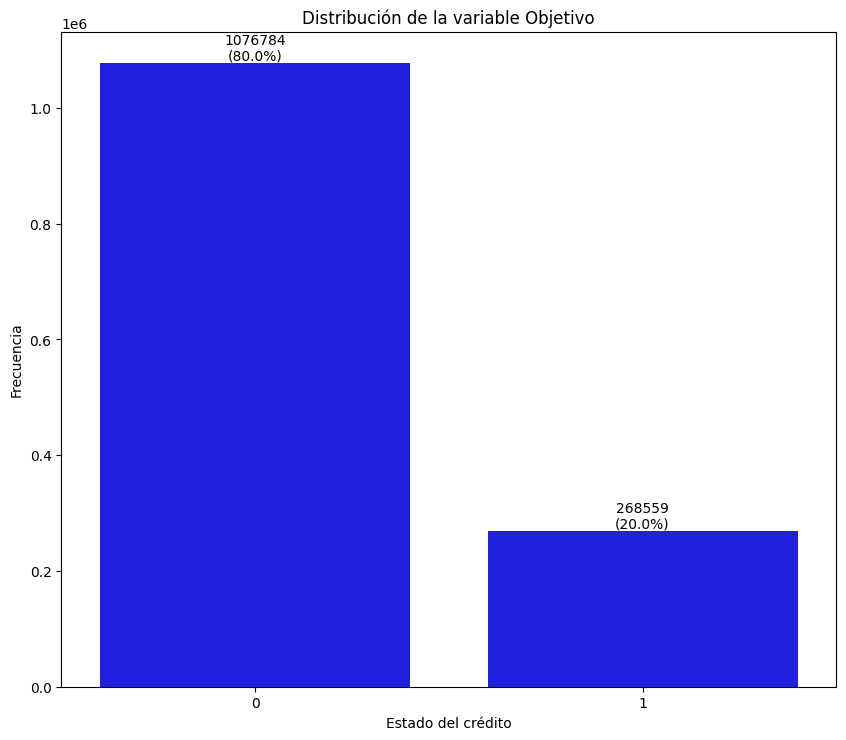

In [24]:
#Gráfico de barras
plt.figure(figsize=(10,8.5))

ax = sns.countplot(data=df, x='default', color='b')

total = len(df)

for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total
    ax.annotate(f'{count}\n({percentage:.1f}%)',
                (p.get_x() + p.get_width() / 2., count),
                ha='center', va='bottom')

plt.title("Distribución de la variable Objetivo")
plt.xlabel("Estado del crédito")
plt.ylabel("Frecuencia")

plt.show()

Del gráfico obtenemos que aproximadamente el 80% de los préstamos (1076784) se encuentran totalmente pagados, y que un 20% (268559) se consideraron incobrables por la entidad prestataria. Se puede observar que el dataset presenta un desbalance de clases moderado, donde la mayoría de los préstamos fueron pagados correctamente y una menor proporción terminó en incumplimiento, por tanto el modelo podría tender a predecir a la clase mayoritaria, sin embargo el desbalance no es extremo, por tanto se puede proceder. Antes de proceder con la descripción de las variables restantes se procede nuevamente a analizar la estructura del dataset:

In [25]:
#Asi quedaria el dataset
pd.options.display.max_rows = 1000
df.head().T

,0,1,2,4,5
loan_amnt,3600.0,24700.0,20000.0,10400.0,11950.0
funded_amnt,3600.0,24700.0,20000.0,10400.0,11950.0
funded_amnt_inv,3600.0,24700.0,20000.0,10400.0,11950.0
term,36 months,36 months,60 months,60 months,36 months
int_rate,13.99,11.99,10.78,22.45,13.44
installment,123.03,820.28,432.66,289.91,405.18
grade,C,C,B,F,C
sub_grade,C4,C1,B4,F1,C3
emp_length,10+ years,10+ years,10+ years,3 years,4 years
home_ownership,MORTGAGE,MORTGAGE,MORTGAGE,MORTGAGE,RENT


Luego de esto observese un resumen de las variables:

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1345343 entries, 0 to 2260700
Data columns (total 69 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   loan_amnt                   1345343 non-null  float64
 1   funded_amnt                 1345343 non-null  float64
 2   funded_amnt_inv             1345343 non-null  float64
 3   term                        1345343 non-null  object 
 4   int_rate                    1345343 non-null  float64
 5   installment                 1345343 non-null  float64
 6   grade                       1345343 non-null  object 
 7   sub_grade                   1345343 non-null  object 
 8   emp_length                  1345343 non-null  object 
 9   home_ownership              1345343 non-null  object 
 10  annual_inc                  1345343 non-null  float64
 11  verification_status         1345343 non-null  object 
 12  purpose                     1345343 non-null  object 
 13  ad

In [27]:
#Variables numéricas
nume_vars = df.select_dtypes(include=['int64', 'float64'])

#Variables categóricas
cat_vars = df.select_dtypes(include=['object', 'category'])

print("Número de variables numéricas:", nume_vars.shape[1])
print("Número de variables categóricas:", cat_vars.shape[1])

Número de variables numéricas: 58
Número de variables categóricas: 11


De este resument obtenemos que cada entrada es explicada por 69 variables de la cuales 58 son númericas y 11 son categóricas. Debido al gran número de variables, se realizará el descriptivo sobre un conjunto de variables consideradas relevantes y aquellas que tengan mayor correlación con la variable objetivo. 

Es importante tener en cuenta que este proyecto se utilizará un modelo de clasificación basado en árboles de decisión **(Random Forest)**, a diferencia de modelos lineales, este algoritmo no se ve significativamente afectado por la multicolinealidad entre variables predictoras, ya que cada árbol del bosque utiliza subconjuntos aleatorios de variables para construir sus particiones. Por esta razón, el análisis de correlación entre variables no es estrictamente necesario para el desempeño del modelo. Sin embargo, durante el Análisis Exploratorio de Datos (EDA) resulta útil examinar la relación entre algunas variables y la variable objetivo con el fin de comprender mejor la estructura del dataset, identificar posibles redundancias y obtener una intuición preliminar sobre qué características podrían tener mayor influencia en la predicción del riesgo de incumplimiento de los préstamos. Con esto explicado, se procede con el análisis de las variables más relevantes.

### Descriptivo de las variables más relevantes 
Debido a la gran cantidad de variables presentes, se decidió realizar el descriptivo de variables para una selección de 10 variables que fueron consideradas las más relevantes para este caso. Primero que todo se analizará la definición de cada una de estas variables y su respectivo tipo:

#### Diccionario de Variables relevantes

- **int_rate (Numérica):** Tasa de interés del préstamo asignada al cliente (expresada en porcentaje anual).  

- **grade (Categórica ordinal):** — Clasificación general del riesgo crediticio asignada por la entidad (A a G), donde A es menor riesgo y G mayor riesgo. Subclasificación del riesgo crediticio del prestatario dentro de cada grade (por ejemplo, A1–G5), donde valores más altos implican mayor riesgo.  

- **credit_history_years (Numérica):** Antigüedad del historial crediticio del cliente, medida en años desde su primera línea de crédito registrada.   

- **revol_util (Numérica):** Porcentaje de utilización del crédito rotativo disponible (cuánto del crédito disponible está siendo utilizado).  

- **mo_sin_old_rev_tl_op (Numérica):** Número de meses desde que se abrió la línea de crédito revolvente más antigua.  

- **installment (Numérica):** Cuota mensual que el prestatario debe pagar por el préstamo.  

- **fico_range_low (Numérica):** Valor inferior del rango del puntaje FICO del prestatario al momento de la evaluación del crédito. Este puntaje refleja la calidad crediticia del cliente, donde valores más altos indican menor riesgo de incumplimiento.

- **dti (Numérica):** Relación deuda-ingreso del prestatario, que mide el porcentaje de sus ingresos mensuales destinados al pago de deudas. 

- **bc_util (Numérica):** Porcentaje de utilización del crédito en tarjetas bancarias.  

- **home_ownership (Categórica Nominal):** Indica el estado de propiedad de la vivienda del prestatario, es decir, si es propietario, arrendatario, tiene hipoteca u otra condición habitacional. Esta variable refleja estabilidad financiera y puede influir en el riesgo crediticio.  

Luego se procede con un análisis univariado de estas variables relevantes:

### Variables númericas:
Para cada variable númerica se realizará una descripción, un histograma y un boxplot para analizar su comportamiento.


In [28]:
num_vars = [
    "int_rate",
    "credit_history_years",
    "revol_util",
    "mo_sin_old_rev_tl_op",
    "installment",
    "fico_range_low",
    "dti",
    "bc_util",
]

df_sample = df.sample(500000, random_state=42)

def plot_boxplots(df, num_vars):
    
    n = len(num_vars)
    cols = 3
    rows = math.ceil(n / cols)
    
    plt.figure(figsize=(5*cols, 4*rows))
    
    for i, col in enumerate(num_vars, 1):
        plt.subplot(rows, cols, i)
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot de {col}")
    
    plt.tight_layout()
    plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
import math

def plot_histograms(df, num_vars, bins=30):
    
    n = len(num_vars)
    cols = 3  # número de columnas en la grilla
    rows = math.ceil(n / cols)
    
    plt.figure(figsize=(5*cols, 4*rows))
    
    for i, col in enumerate(num_vars, 1):
        plt.subplot(rows, cols, i)
        sns.histplot(df[col].dropna(), bins=bins)
        plt.title(f"Histograma de {col}")
    
    plt.tight_layout()
    plt.show()
    
def describe_variables(df, num_vars):
    
    desc = df[num_vars].describe().T
    
    # Agregar métricas extra útiles
    desc["median"] = df[num_vars].median()
    desc["missing"] = df[num_vars].isna().sum()
    
    return desc

describe_variables(df_sample, num_vars)

,count,mean,std,min,25%,50%,75%,max,median,missing
int_rate,500000.0,13.231713,4.767697,5.310000,9.750000,12.740000,15.990000,30.990000,12.740000,0
credit_history_years,500000.0,27.070418,7.616554,10.556164,21.813699,25.734247,30.989041,92.030137,25.734247,0
revol_util,500000.0,51.799806,24.489949,0.000000,33.500000,52.200000,70.700000,184.600000,52.200000,0
mo_sin_old_rev_tl_op,500000.0,180.689756,92.087175,2.000000,120.000000,164.000000,226.000000,842.000000,164.000000,0
installment,500000.0,438.321812,261.588959,14.010000,248.480000,375.060000,580.730000,1717.630000,375.060000,0
fico_range_low,500000.0,696.212520,31.883755,630.000000,670.000000,690.000000,710.000000,845.000000,690.000000,0
dti,500000.0,18.261951,10.001487,0.000000,11.820000,17.620000,24.060000,991.570000,17.620000,0
bc_util,500000.0,59.983350,27.627103,0.000000,39.600000,61.000000,83.900000,339.600000,61.000000,0


El análisis descriptivo de las variables numéricas muestra que, en general, no existen valores faltantes, lo que indica una buena calidad inicial de los datos. Variables como **int_rate** presentan una distribución relativamente centrada (media cercana a la mediana), lo que sugiere una leve asimetría positiva y una adecuada dispersión en las tasas de interés asignadas. De manera similar, **fico_range_low** evidencia una concentración en rangos medios–altos de puntaje crediticio, lo cual sugiere que la mayoría de los prestatarios posee un perfil de riesgo moderado. Por otro lado, variables como **credit_history_years** y **mo_sin_old_rev_tl_op** muestran que gran parte de los clientes cuenta con una larga trayectoria crediticia, aunque con alta variabilidad, lo que puede aportar valor predictivo al modelo.

Sin embargo, se identifican valores atípicos y posibles inconsistencias en variables clave como **revol_util**, **bc_util** y especialmente **dti**, donde se observan máximos extremadamente altos y valores no válidos (por ejemplo, -1 o 999). Estos comportamientos indican la presencia de outliers o errores de registro que podrían afectar negativamente el desempeño de los modelos si no se tratan adecuadamente. Asimismo, variables como **installment** presentan una dispersión considerable y sesgo hacia la derecha, reflejando la existencia de préstamos con cuotas significativamente altas. En conjunto, estos hallazgos resaltan la necesidad de realizar un proceso de limpieza y tratamiento de outliers antes de proceder con el modelado.

c:\Users\User\.conda\envs\dataviz_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\.conda\envs\dataviz_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\.conda\envs\dataviz_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\.conda\envs\dataviz_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a fu

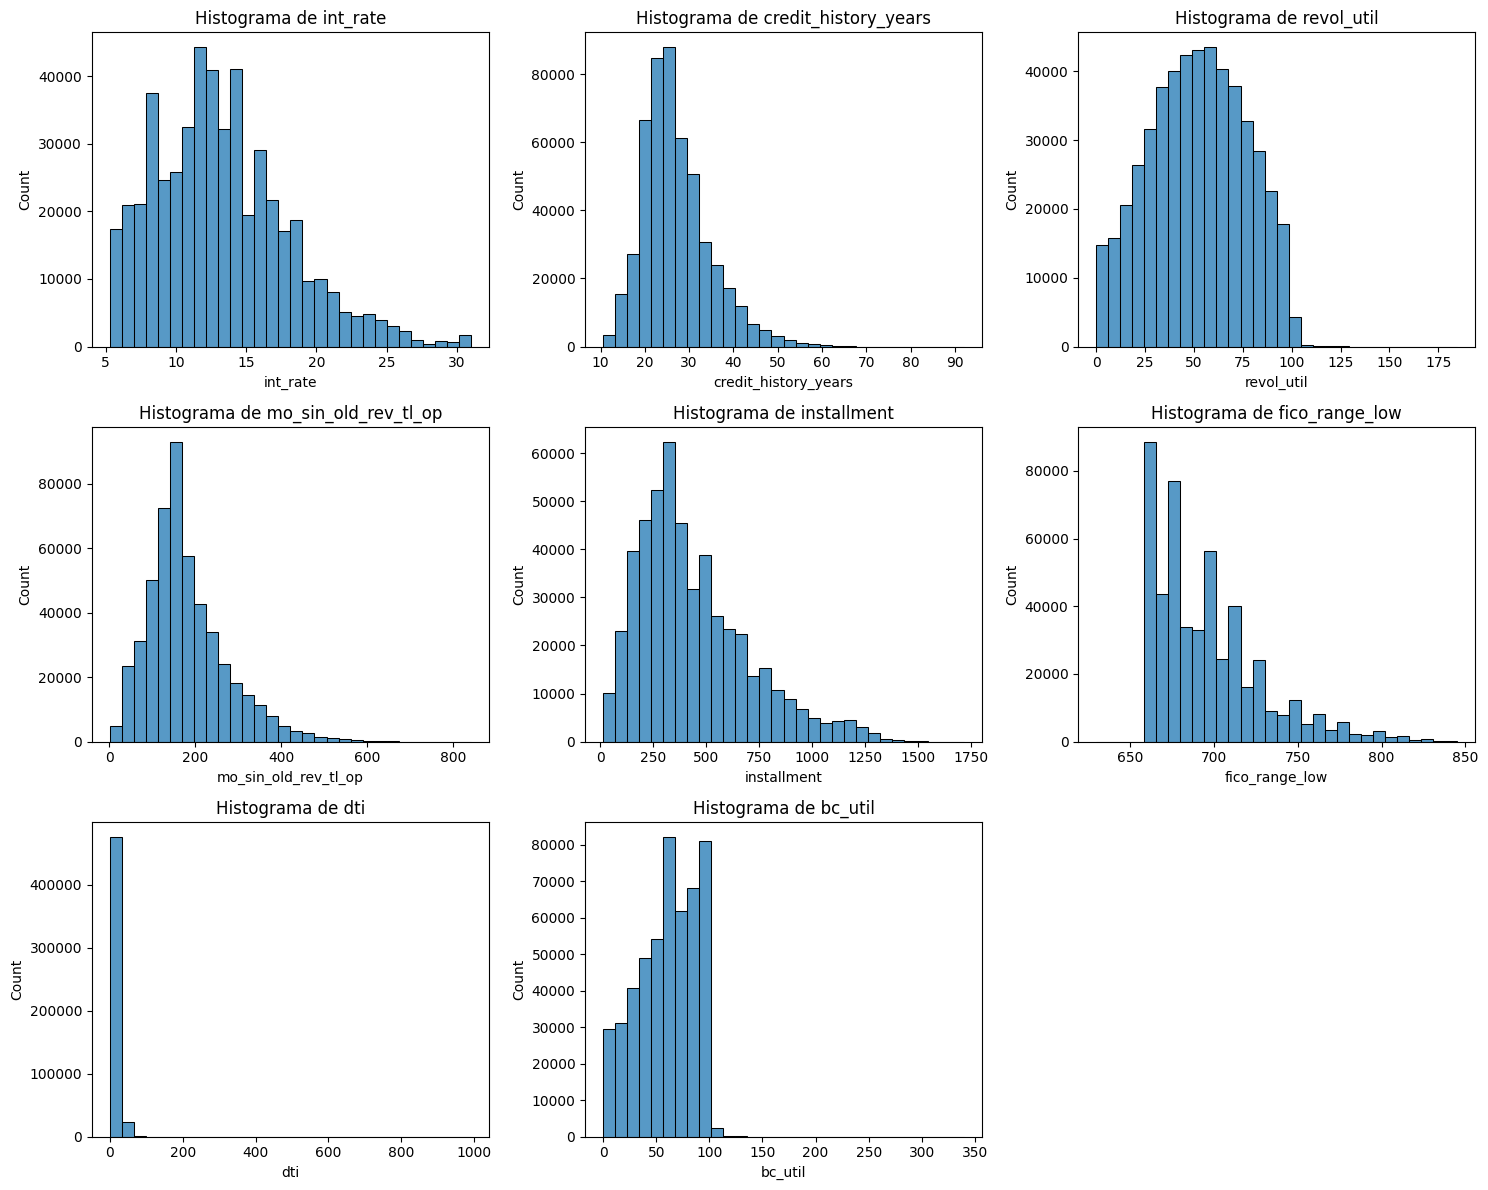

In [29]:
plot_histograms(df_sample, num_vars)

El análisis de los histogramas permite observar la forma de distribución de las variables numéricas y complementa los resultados descriptivos previos. Variables como **int_rate**, **revol_util** y **credit_history_years** presentan distribuciones relativamente suaves, con una ligera asimetría positiva, lo que indica que la mayoría de los valores se concentran en rangos medios, pero existen algunos valores altos que generan colas hacia la derecha. En particular, **credit_history_years** y **mo_sin_old_rev_tl_op** evidencian que una gran proporción de los clientes tiene historiales crediticios largos, aunque con presencia de valores extremos. Por su parte, **installment** también muestra una distribución sesgada a la derecha, reflejando que existen préstamos con cuotas significativamente mayores al promedio.

En contraste, variables como **dti** y **bc_util** presentan distribuciones altamente sesgadas con colas largas y concentraciones anómalas, lo que confirma la presencia de outliers. En el caso de **dti**, se observa una fuerte acumulación de valores bajos junto con valores extremadamente altos, lo que sugiere la existencia de registros atípicos. Asimismo, **fico_range_low** muestra una distribución más discreta y concentrada en ciertos rangos, coherente con la naturaleza de los puntajes crediticios. 

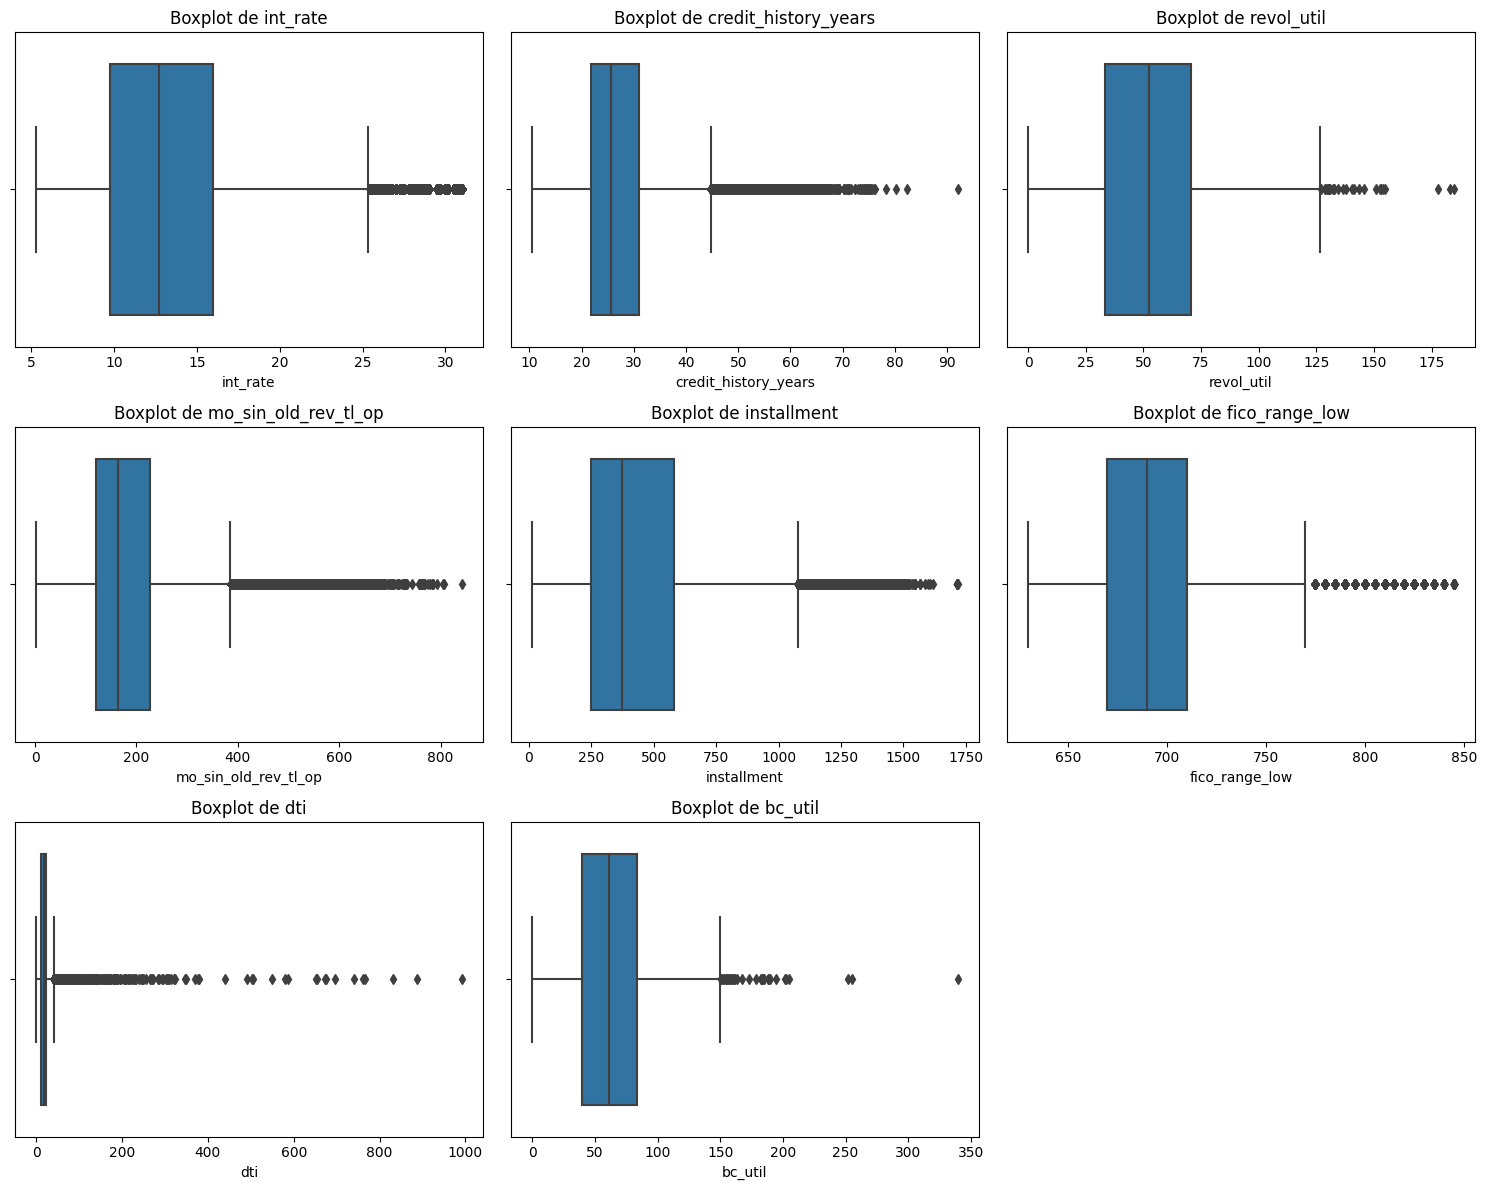

In [30]:
plot_boxplots(df_sample, num_vars)

El análisis de los boxplots permite identificar de manera clara la presencia de valores atípicos y la dispersión de las variables. En general, variables como **int_rate**, **installment** y **revol_util** presentan una distribución relativamente estable en su rango intercuartílico, aunque con presencia de outliers hacia valores altos, lo que confirma una ligera asimetría positiva observada previamente. Por su parte, **credit_history_years** y **mo_sin_old_rev_tl_op** muestran una concentración de datos en rangos medios, pero con una cantidad considerable de valores extremos superiores, reflejando la heterogeneidad en la antigüedad del historial crediticio de los clientes.

En contraste, variables como **dti** y **bc_util** evidencian una gran cantidad de outliers, especialmente hacia la derecha, lo que indica la presencia de valores extremos y posiblemente errores o registros atípicos que requieren tratamiento. En particular, **dti** presenta una fuerte concentración en valores bajos con una larga cola de valores extremos. Finalmente, **fico_range_low** muestra una distribución más controlada, con menor dispersión relativa, aunque también con algunos valores atípicos en los extremos superiores. 

Observemos ahora la correlación de la variable objetivo con algunas variables categóricas. Inicialmente se utilizará una matriz de correlación que muestre la relación de las variables númericas con la variable objetivo, esto se puede hacer ya que al ser númerica binaria se puede aplicar *point-Biserial*, y se tomarán las 10 variables con mayor coeficiente de correlación para ser estudiadas:




In [31]:
#calcular correlación
corr = nume_vars.corr()['default'].drop('default')
    
#ordenar por magnitud
corr = corr.sort_values(key=abs, ascending=False)

top_vars = corr.head(10).index.tolist()

top_vars.append('default')


print(corr)

int_rate                      0.258792
fico_range_low               -0.130680
fico_range_high              -0.130679
acc_open_past_24mths          0.099429
dti                           0.095302
num_tl_op_past_12m            0.084398
bc_open_to_buy               -0.078863
avg_cur_bal                  -0.074723
tot_hi_cred_lim              -0.074579
mort_acc                     -0.072463
num_actv_rev_tl               0.070444
total_bc_limit               -0.069878
num_rev_tl_bal_gt_0           0.069028
tot_cur_bal                  -0.067082
percent_bc_gt_75              0.066944
funded_amnt                   0.065660
loan_amnt                     0.065606
inq_last_6mths                0.065462
funded_amnt_inv               0.065447
bc_util                       0.064792
revol_util                    0.060028
mo_sin_rcnt_tl               -0.052637
installment                   0.051703
mo_sin_rcnt_rev_tl_op        -0.050791
total_rev_hi_lim             -0.050408
mths_since_recent_bc     

Se observa que no hay variables que se encuentren fuertemente correlacionadas con la variable objetivo, se puede visualizar fácilmente tomando un heatmap con las 10 variables con mayor coeficiente de correlación:

<Axes: >

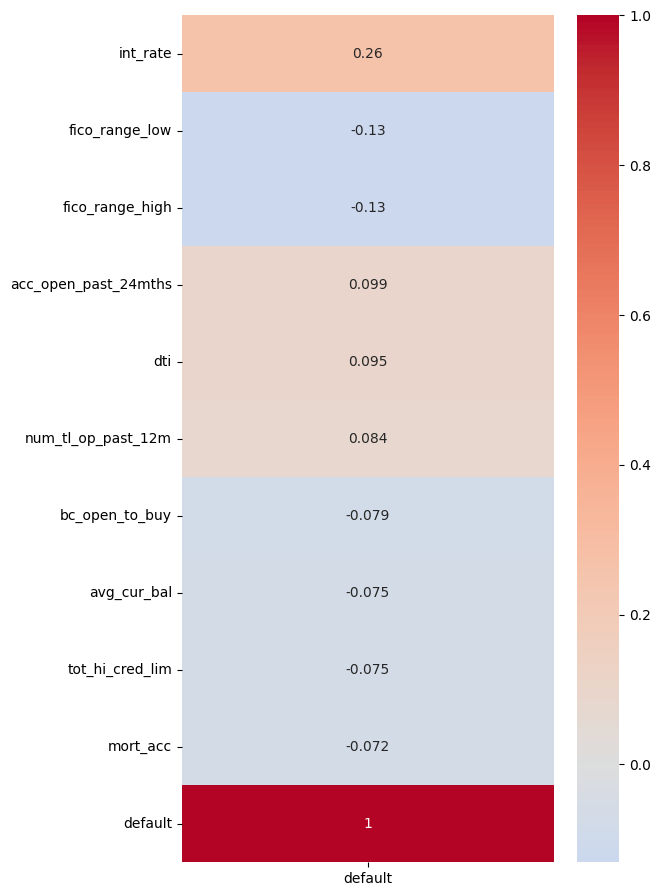

In [32]:
plt.figure(figsize=(6,11))

sns.heatmap(
    df[top_vars].corr()[['default']],
    annot=True,
    cmap='coolwarm',
    center=0
)

Ninguno de los coeficientes de correlación supera el 0.30, lo que indica poca correlación de las variables númericas con la variable objetivo, sin embargo, esto no representa ningún obstaculo debido a lo explicado anteriormente sobre el funcionamiento de Random Forest.

### Variables Categóricas:
Pasemos con el análisis de algunas variables númericas del dataset:

- **grade (Categórica ordinal):** 

Primero observemos la frecuencia absoluta:



In [33]:
df["grade"].value_counts()

grade
B    392774
C    381686
A    235090
D    200953
E     93650
F     32058
G      9132
Name: count, dtype: int64

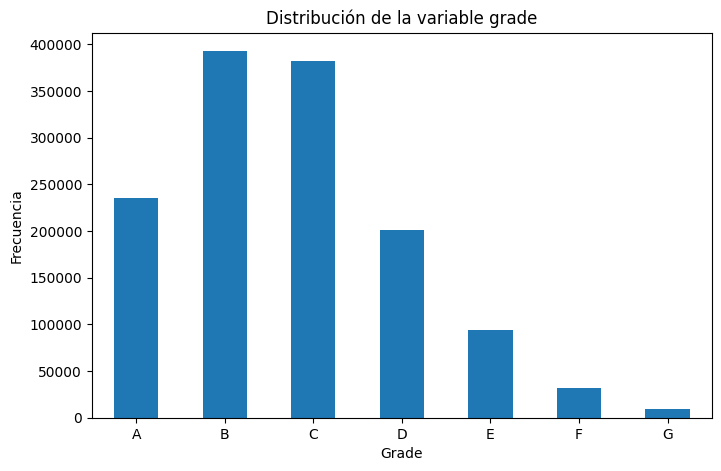

In [34]:
import matplotlib.pyplot as plt

# Contar valores y ordenar (A → G)
conteo = df["grade"].value_counts().sort_index()

# Gráfico de barras
plt.figure(figsize=(8,5))
conteo.plot(kind="bar")

plt.title("Distribución de la variable grade")
plt.xlabel("Grade")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)

plt.show()

La variable grade presenta una distribución claramente desbalanceada, donde las categorías intermedias concentran la mayor proporción de los préstamos. En particular, los grados B y C son los más frecuentes, seguidos por A y D, mientras que las categorías de mayor riesgo (E, F y G) representan una proporción considerablemente menor del total. Esto sugiere que la mayoría de los préstamos otorgados se ubican en niveles de riesgo medio, lo cual es consistente con políticas crediticias que buscan equilibrar riesgo y rentabilidad. Por otro lado, la baja representación de los grados más altos de riesgo podría influir en el desempeño del modelo, ya que tendrá menos ejemplos para aprender patrones asociados a estos casos, lo que debe tenerse en cuenta en el análisis posterior.

In [35]:
df["grade"].value_counts(normalize=True)*100

grade
B    29.195083
C    28.370906
A    17.474354
D    14.936934
E     6.961050
F     2.382887
G     0.678786
Name: proportion, dtype: float64

La distribución relativa de la variable grade confirma un marcado desbalance hacia las categorías de riesgo medio. Los grados B y C concentran conjuntamente más del 57% de los préstamos, seguidos por A (17.47%) y D (14.94%), mientras que las categorías de mayor riesgo (E, F y G) representan en conjunto menos del 10% del total. Esto indica que la mayoría de los créditos otorgados se encuentran en niveles intermedios de riesgo, con una participación muy limitada de préstamos altamente riesgosos. Desde el punto de vista del modelado, esta distribución puede influir en la capacidad del modelo para aprender patrones asociados a las categorías menos representadas, especialmente en los grados más altos, lo que podría afectar su desempeño en estos segmentos específicos.

In [36]:
pd.crosstab(df["grade"], df["default"], normalize='index')

default,0,1
grade,,
A,0.939593,0.060407
B,0.866160,0.133840
C,0.775604,0.224396
D,0.696178,0.303822
E,0.615216,0.384784
F,0.547976,0.452024
G,0.500657,0.499343


La variable **grade** muestra una relación clara y monotónica con la probabilidad de incumplimiento. A medida que el grado de riesgo empeora desde A hasta G, la proporción de préstamos en default aumenta de forma progresiva. En particular, los préstamos de grado A presentan una tasa de incumplimiento muy baja (6.04%), mientras que en los grados intermedios como C y D esta proporción crece significativamente (22.44% y 30.38%, respectivamente). Este comportamiento se acentúa en los grados más altos de riesgo, donde casi la mitad de los préstamos en la categoría G entran en default (49.93%). Este patrón evidencia una fuerte capacidad predictiva de la variable, ya que permite discriminar claramente entre distintos niveles de riesgo crediticio, siendo una de las variables más relevantes para el modelo.

- **home_ownership (Categórica nominal):**

In [37]:
df["home_ownership"].value_counts()

home_ownership
MORTGAGE    665612
RENT        534421
OWN         144832
ANY            286
OTHER          144
NONE            48
Name: count, dtype: int64

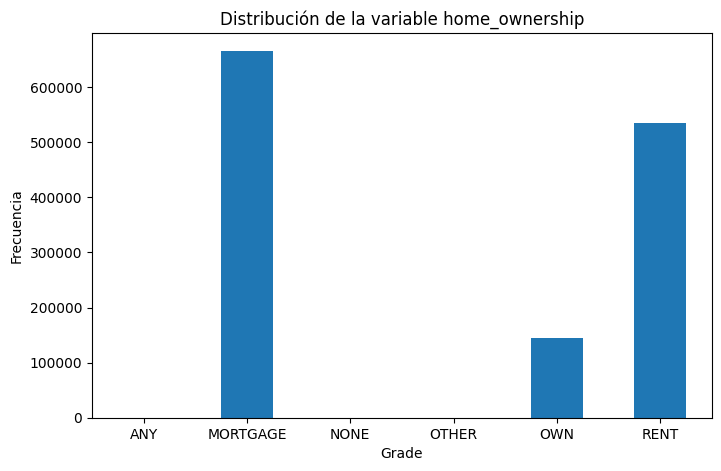

In [38]:
import matplotlib.pyplot as plt

# Contar valores y ordenar (A → G)
conteo = df["home_ownership"].value_counts().sort_index()

# Gráfico de barras
plt.figure(figsize=(8,5))
conteo.plot(kind="bar")

plt.title("Distribución de la variable home_ownership")
plt.xlabel("Grade")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)

plt.show()

La variable **home_ownership** presenta una distribución altamente concentrada en tres categorías principales: MORTGAGE, RENT y OWN. En particular, la categoría MORTGAGE es la más frecuente con 665,612 observaciones, seguida por RENT con 534,421, lo que indica que la mayoría de los prestatarios se encuentran pagando una hipoteca o en condición de arrendamiento. Por otro lado, la categoría OWN tiene una representación considerablemente menor (144,832), mientras que las categorías ANY, OTHER y NONE son prácticamente insignificantes en términos de frecuencia, con muy pocas observaciones.

Este comportamiento sugiere que la variable está desbalanceada y que las categorías minoritarias podrían no aportar información significativa al modelo debido a su baja representación. En consecuencia, podría ser conveniente agrupar o eliminar estas categorías poco frecuentes en etapas posteriores del análisis, con el fin de evitar ruido y mejorar la capacidad predictiva del modelo.

In [39]:
df["home_ownership"].value_counts(normalize=True)*100

home_ownership
MORTGAGE    49.475264
RENT        39.723773
OWN         10.765433
ANY          0.021259
OTHER        0.010704
NONE         0.003568
Name: proportion, dtype: float64

La distribución relativa de la variable **home_ownership** muestra una alta concentración en dos categorías principales: MORTGAGE y RENT, que representan aproximadamente el 49.48% y 39.72% de los casos, respectivamente. Esto indica que cerca del 90% de los prestatarios se encuentran ya sea pagando una hipoteca o viviendo en arriendo, lo cual sugiere que la mayoría no posee completamente su vivienda. Por su parte, la categoría OWN tiene una participación mucho menor (10.77%), mientras que las categorías ANY, OTHER y NONE son prácticamente insignificantes, con proporciones cercanas a cero.

Este fuerte desbalance implica que la variable está dominada por unas pocas categorías, lo cual puede influir en el modelo al darle mayor peso a estas. Además, las categorías minoritarias podrían no aportar información significativa debido a su baja representación, por lo que sería recomendable considerar su agrupación o eliminación para evitar introducir ruido en el modelo.

In [40]:
pd.crosstab(df["home_ownership"], df["default"], normalize='index')

default,0,1
home_ownership,,
ANY,0.804196,0.195804
MORTGAGE,0.827931,0.172069
NONE,0.854167,0.145833
OTHER,0.812500,0.187500
OWN,0.793802,0.206198
RENT,0.767835,0.232165


La relación entre la variable **home_ownership** y el estado del préstamo (**default**) no muestra diferencias tan marcadas como en otras variables, aunque sí se observan ciertas tendencias relevantes. En particular, los prestatarios en condición de RENT presentan la mayor proporción de incumplimiento (23.22%), seguidos por aquellos que poseen vivienda propia (OWN) con un 20.62%. En contraste, las categorías MORTGAGE y NONE presentan menores tasas de default (17.21% y 14.58%, respectivamente), lo que sugiere que estos perfiles podrían estar asociados a un menor riesgo crediticio.

Sin embargo, las diferencias entre categorías no son extremadamente pronunciadas, lo que indica que, aunque home_ownership tiene cierta capacidad explicativa, su poder predictivo es moderado en comparación con variables como grade. Adicionalmente, las categorías ANY, OTHER y NONE tienen muy poca representación en el dataset, por lo que las conclusiones sobre estas deben tomarse con cautela, ya que podrían no ser estadísticamente robustas.


Una vez análizadas estas variables, pasemos a la construcción del modelo con scikit-learn.

# Scikit-learn

Para el modelo de Random Forest en scikit-learn se realizará inicialmente un modelo con hiperparametros medios que incluya todas las variables, luego de eso se empleará la función *Feature Importance* para determinar un conjunto de 20 variables relevantes, que en conjunto al criterio del equipo, se utilizarán para crear un nuevo conjunto de 20 variables relevantes con las que se reentrenará el modelo y se analizarán los resultados:

## Preprocesamiento:

Para este caso se emplearán 3 técnicas de imputación para evitar la creación masiva de variables:

- **OneHot Encoding:** convierte cada etiqueta de la variable en una variable booleana que indica si la entrada pertene a la etiqueta o no. Debido a que si se aplica a variables con una gran cantidad de etiquetas se generan demasiadas variables, se tomó la decisión de aplicar esta codficación a variables con pocas etiquetas y que no sigan ningún tipo de jerarquía.

- **Label Encoding:** convierte cada etiqueta de la variable a una etiqueta númerica entera. Para evitar que el modelo pierda precisión, esta codificación solo se aplico a las variables que sigan alguna jerarquía interna en sus etiquetas, como por ejemplo la variable "grade".

- **Frequency Encoding:** convierte cada etiqueta en la frecuencia de la misma. Ideal para la variable "addr_state" que no posee una jerarquía interna y que tiene una gran cantidad de etiquetas, ya que son 50 estados los que representa.

In [41]:

df_OneHot = df

#Aplicar label encoding para variables que tengan alguna jerarquia interna
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

label_cols = ['term','grade','sub_grade','emp_length']

for col in label_cols:
    le = LabelEncoder()
    df_OneHot[col] = le.fit_transform(df_OneHot[col])
    
#OneHot para variables que no sigan alguna jerarquia o que tengan pocas etiquetas
df_OneHot = pd.get_dummies(
    df_OneHot,
    columns=[
        'home_ownership',
        'verification_status',
        'purpose',
        'initial_list_status',
        'application_type',
        'disbursement_method'
    ],
    drop_first=True
)

#Frequency encoding para addr_state
freq = df_OneHot['addr_state'].value_counts(normalize=True)
df_OneHot['addr_state_freq'] = df_OneHot['addr_state'].map(freq)

df_OneHot = df_OneHot.drop(columns=['addr_state'])

Una vez completada la imputación se verifica nuevamente las dimensiones resultantes del dataset y que no existan valores NaN:

In [42]:
df_OneHot.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1345343 entries, 0 to 2260700
Data columns (total 86 columns):
 #   Column                               Non-Null Count    Dtype  
---  ------                               --------------    -----  
 0   loan_amnt                            1345343 non-null  float64
 1   funded_amnt                          1345343 non-null  float64
 2   funded_amnt_inv                      1345343 non-null  float64
 3   term                                 1345343 non-null  int32  
 4   int_rate                             1345343 non-null  float64
 5   installment                          1345343 non-null  float64
 6   grade                                1345343 non-null  int32  
 7   sub_grade                            1345343 non-null  int32  
 8   emp_length                           1345343 non-null  int32  
 9   annual_inc                           1345343 non-null  float64
 10  dti                                  1345343 non-null  float64
 11  del

Al final se obtienen 86 variables que caracterizan a las entradas luego de la codificación, con este proceso realizado, ya es posible empezar a diseñar los primeros modelos. Para la optimización de los modelos, inicialmente se trabajará con todos las variables en un modelo de Random Forest empleando Scikit-Learn, para luego emplear la función **Feature importance**, que determina el nivel de importancia o utilidad de la variable para el modelo, de esta manera se tomará una selección de 20 variables que luego serán empleadas en los modelos finales.

## Primer modelo
Se hará el primer modelo con la totalidad de las variables:

In [43]:
#Se separan X y Y
X = df_OneHot.drop("default", axis=1)
y = df_OneHot["default"]


Luego de eso se procede a realizar el split y definir los hiperparametros, no se realiza estandarización ya que para el modelo Random Forest no es necesario, como es el primer modelo, se utilizarán 50 estimadores con profundidad 10:

In [44]:
model = RandomForestClassifier()
scaler = StandardScaler()


param_grid = {
    'n_estimators': [50],
    'max_depth': [10],
    'class_weight': ['balanced']
}


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_test, y_train, y_test = X_train.values, X_test.values, y_train.values, y_test.values

Luego de esto se procede a la construcción del modelo utilizando Grid Search para realizar validación cruzada utilizando 3 pliegues, de esta manera evitando posible sobreajuste, inmediatamente se entrena el modelo:

In [45]:
start = time.time()
grid = GridSearchCV(model, param_grid=param_grid, scoring='recall', cv=3, n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
best_model.fit(X_train, y_train)


y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

elapsed_sklearn = time.time() - start

Una vez entrenado el modelo, se procede a visualizar y analizar los resultados obtenidos, es importante resaltar que las métricas de análisis que se están usando son ponderadas, es decir, se está trabajdno con el *recall* ponderado:


GridSearchCV (scikit-learn)
Best n_estimators: 50
Best max_depth: 10
Test accuracy: 0.6377
Test precision: 0.7723
Test recall: 0.6377
Test f1: 0.6736
Test AUC: 0.7135
Tiempo: 5 minutos, y 18 segundos


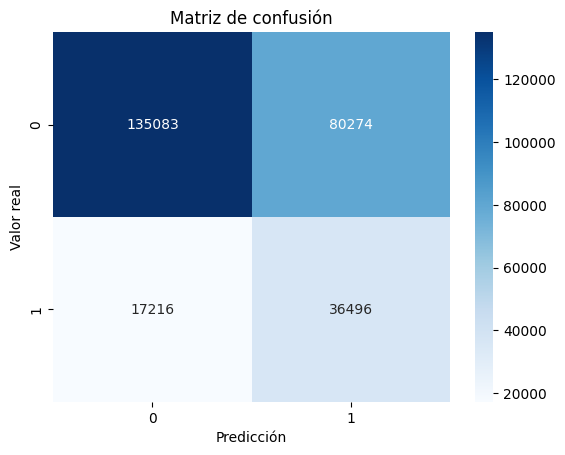

In [46]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc = roc_auc_score(y_test, y_prob)

metrics = [accuracy, precision, recall, f1]
names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred))

print("\nGridSearchCV (scikit-learn)")
print("Best n_estimators:", grid.best_params_['n_estimators'])
print("Best max_depth:", grid.best_params_['max_depth'])
print("Test accuracy: {:.4f}".format(accuracy))
print("Test precision: {:.4f}".format(precision))
print("Test recall: {:.4f}".format(recall))
print("Test f1: {:.4f}".format(f1))
print("Test AUC: {:.4f}".format(roc))
print("Tiempo: {:.0f} minutos, y {:.0f} segundos".format(int(elapsed_sklearn//60),int(elapsed_sklearn%60)))

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión")

plt.show()

Una vez vistos los resultados, se procede a utilizar *Feature importance* para obtener las variables que fueron más importantes para la predicción según el modelo:

In [47]:
import pandas as pd

feature_importance = pd.Series(
    best_model.feature_importances_,
    index = X.columns).sort_values(ascending=False)

feature_importance.head(20)

sub_grade                  0.210071
int_rate                   0.177269
grade                      0.174468
term                       0.073431
dti                        0.031029
fico_range_high            0.030407
fico_range_low             0.024677
acc_open_past_24mths       0.020549
avg_cur_bal                0.020125
tot_hi_cred_lim            0.017015
funded_amnt                0.015933
funded_amnt_inv            0.014393
installment                0.013262
loan_amnt                  0.013041
tot_cur_bal                0.012775
annual_inc                 0.011591
num_tl_op_past_12m         0.010370
bc_open_to_buy             0.008937
mort_acc                   0.008830
home_ownership_MORTGAGE    0.006881
dtype: float64

## Reentranamiento del modelo

Realizando un combinado de estas variables anteriormente obtenidas y de otras variables consideradas relevantes se vuelve a realizar el modelo con la siguiente lista de variables y utilizando la lista completas de hiperparametros para determinar cuales son los hiperparamentros más efectivos:

In [48]:
top_features = [
'int_rate',
'dti',
'sub_grade',
'credit_history_years',
'annual_inc',
'revol_util',
'mo_sin_old_rev_tl_op',
'revol_bal',
'installment',
'mo_sin_old_il_acct',
'tot_hi_cred_lim',
'avg_cur_bal',
'bc_open_to_buy',
'bc_util',
'total_bc_limit',
'total_rev_hi_lim',
'tot_cur_bal',
'total_bal_ex_mort',
'grade',
'total_il_high_credit_limit',
'default'
]

#Separación de la variable objetivo

#Se separan X y Y
X = df_OneHot[top_features].drop("default", axis=1)
y = df_OneHot["default"]

In [49]:
model = RandomForestClassifier()
scaler = StandardScaler()


param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [5, 15, 100],
    'class_weight': ['balanced']
}


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_test, y_train, y_test = X_train.values, X_test.values, y_train.values, y_test.values

In [50]:
start = time.time()
grid = GridSearchCV(model, param_grid=param_grid, scoring='recall', cv=3, n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
best_model.fit(X_train, y_train)


y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

elapsed_sklearn = time.time() - start


GridSearchCV (scikit-learn)
Best n_estimators: 50
Best max_depth: 5
Test accuracy: 0.5962
Test precision: 0.7700
Test recall: 0.5962
Test f1: 0.6365
Test AUC: 0.6977
Tiempo: 13 minutos, y 3 segundos


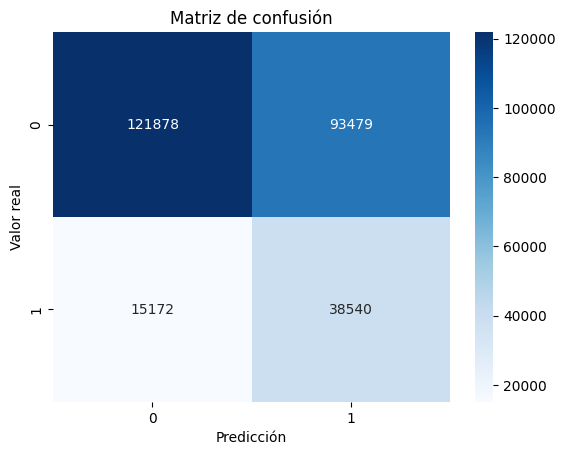

In [51]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc = roc_auc_score(y_test, y_prob)

metrics = [accuracy, precision, recall, f1]
names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

conf_matrix = pd.DataFrame(confusion_matrix(y_test, y_pred))

print("\nGridSearchCV (scikit-learn)")
print("Best n_estimators:", grid.best_params_['n_estimators'])
print("Best max_depth:", grid.best_params_['max_depth'])
print("Test accuracy: {:.4f}".format(accuracy))
print("Test precision: {:.4f}".format(precision))
print("Test recall: {:.4f}".format(recall))
print("Test f1: {:.4f}".format(f1))
print("Test AUC: {:.4f}".format(roc))
print("Tiempo: {:.0f} minutos, y {:.0f} segundos".format(int(elapsed_sklearn//60),int(elapsed_sklearn%60)))

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión")

plt.show()

En conjunto, el modelo Random Forest optimizado mediante GridSearchCV (max_depth: 5, n_estimators: 50) logra una moderada capacidad para detectar préstamos en riesgo de default, alcanzando un recall cercano al 60%. Se obtiene una buena precisión cercana al 77%, el modelo muestra un mejor equilibrio entre detección de riesgo y reducción de falsos positivos, reflejado en el incremento del F1 Score. La capacidad de discriminación moderada evidenciada por el ROC AUC indica que el modelo captura patrones relevantes en los datos, aunque todavía existen oportunidades de mejora mediante técnicas adicionales de manejo de desbalance o el uso de algoritmos más avanzados.  

La matriz de confusión muestra que el modelo tiene una alta capacidad para detectar préstamos que entrarán en default, reflejada en el número elevado de verdaderos positivos y el relativamente bajo número de falsos negativos. Sin embargo, esta capacidad se logra a costa de un número considerable de falsos positivos, lo que significa que el modelo tiende a clasificar como riesgosos a muchos clientes que en realidad sí pagarían sus préstamos. En un contexto financiero, esto implica un trade-off entre reducir el riesgo de impago y mantener oportunidades de otorgamiento de crédito, por lo que futuros ajustes del modelo podrían enfocarse en mejorar la precisión sin perder demasiada capacidad de detección de defaults.

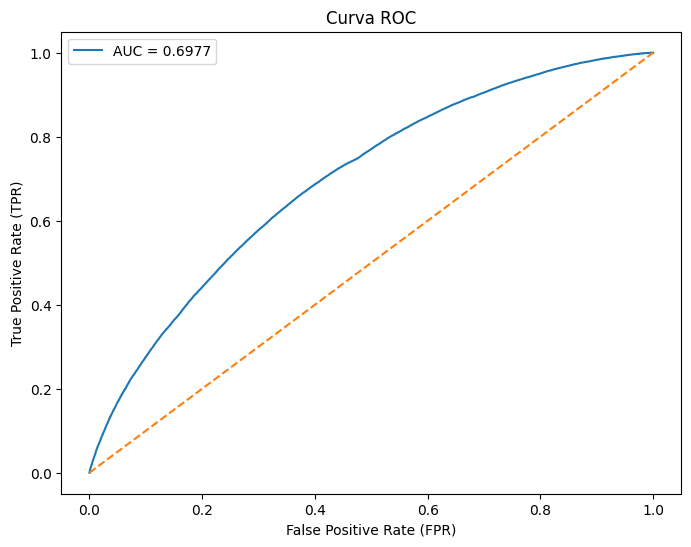

In [52]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calcular FPR y TPR
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calcular AUC
auc = roc_auc_score(y_test, y_prob)

# Graficar
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")  # línea base

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Curva ROC")
plt.legend()

plt.show()

La curva ROC obtenida muestra que el modelo tiene una capacidad de discriminación moderada entre las clases de préstamos en default y no default. El valor del AUC (Área Bajo la Curva) es aproximadamente 0.6977, lo que indica que el modelo es capaz de distinguir correctamente entre ambas clases cerca del 70% de las veces, superando significativamente el comportamiento de un clasificador aleatorio (AUC = 0.5), pero aún lejos de un modelo altamente preciso. La forma de la curva evidencia que el modelo logra mejorar la tasa de verdaderos positivos (recall) a medida que aumenta la tasa de falsos positivos, lo cual es esperable. Sin embargo, la curva no se aproxima de forma pronunciada a la esquina superior izquierda, lo que sugiere que existe margen de mejora en la capacidad predictiva del modelo. En términos prácticos, el modelo tiene un desempeño aceptable para identificar clientes en riesgo, pero aún presenta limitaciones para lograr una separación más clara entre clases. Esto indica que podrían explorarse mejoras en la selección de variables, ajuste de hiperparámetros o incluso el uso de modelos más complejos para incrementar su rendimiento.

# Análisis de resultados con LIME
Se procede ahora a analizar los resultados obtenidos por el modeloutilizando LIME.

In [53]:
import numpy as np  
#encontremos donde se equivoco el modelo 
errores = np.where(y_pred != y_test)[0]


print(f"Total de errores: {len(errores)}")
# Falsos Negativos: era Charged Off pero predijo Fully Paid
fn_indices = np.where((y_pred == 0) & (y_test == 1))[0]

# Falsos Positivos: era Fully Paid pero predijo Charged Off  
fp_indices = np.where((y_pred == 1) & (y_test == 0))[0]

print(f"Falsos Negativos : {len(fn_indices)}")
print(f"Falsos Positivos : {len(fp_indices)}")

Total de errores: 108651
Falsos Negativos : 15172
Falsos Positivos : 93479


In [54]:
# Tomamos uno de cada tipo
idx_fn = fn_indices[0]  
idx_fp = fp_indices[0]  

In [55]:
# Crear el explicador
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train,
    feature_names=X.columns.tolist(),
    class_names=["Fully Paid", "Charged Off"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

In [ ]:
#Falso Negativo
exp_fn = explainer.explain_instance(
    data_row=X_test[idx_fn],
    predict_fn=best_model.predict_proba,  
    num_features=10
)

print("FALSO NEGATIVO")
print(f"Valor real:     Charged Off")
print(f"Valor predicho: Fully Paid")
exp_fn.show_in_notebook(show_table=True)

FALSO NEGATIVO
Valor real:     Charged Off
Valor predicho: Fully Paid


El modelo predijo que este préstamo sería pagado completamente  con una probabilidad del 65%, cuando en realidad terminó en default. 
Las variables que llevaron al modelo a equivocarse fueron bastante contundentes: el grade (calificación del préstamo) con valor de 1, correspondiente a la categoría A, la más alta y segura en la escala de Lending Club, lo que históricamente se asocia casi siempre con buenos pagadores; el sub_grade (subgrado del préstamo) de 7, reforzando esa clasificación de bajo riesgo; el avg_cur_bal (balance promedio actual) de 27,626, indicando que el cliente manejaba volúmenes de crédito considerables de forma activa; la int_rate (tasa de interés) de 12.12%, que al estar entre 9.75% y 12.74% se ubicaba por debajo de la media del dataset, señal de que la propia plataforma lo catalogó como cliente confiable; y el tot_hi_cred_lim (límite total histórico de crédito) de $384,832, evidenciando que múltiples instituciones financieras le habían otorgado límites muy altos a lo largo de su vida crediticia, junto con el tot_cur_bal (balance total actual) de $359,135, que confirmaba un manejo extenso y sostenido de crédito.  

Sin embargo, las señales que apuntaban hacia el default fueron ignoradas: el dti (ratio deuda-ingreso) de 19.39 se encontraba en un rango elevado entre 17.62 y 24.06, indicando que casi una quinta parte de sus ingresos estaba comprometida en pagos de deuda; el installment (cuota mensual del préstamo) de $249.54 superaba el umbral de $248.45, añadiendo presión adicional a su carga financiera mensual; el total_rev_hi_lim (límite total de crédito renovable) de $20,600 era sorprendentemente bajo comparado con su límite histórico total, sugiriendo que su capacidad de crédito disponible se había reducido considerablemente; y los credit_history_years (años de historial crediticio) de 24.55 años, que aunque parecen positivos, en combinación con un DTI alto pueden indicar que el cliente acumuló deuda progresivamente a lo largo de décadas sin reducirla. En conjunto, el modelo se dejó dominar por la excelente calificación A del préstamo y la tasa de interés baja, sin detectar que la combinación de un DTI elevado, cuotas altas y un límite renovable reducido estaba generando una presión financiera real que finalmente derivó en default.

In [57]:
#falsopos
exp_fp = explainer.explain_instance(
    data_row=X_test[idx_fp],
    predict_fn=best_model.predict_proba,  
    num_features=10
)

print("FALSO POSITIVO")
print(f"Valor real:     Fully Paid")
print(f"Valor predicho: Charged Off")
exp_fp.show_in_notebook(show_table=True)


FALSO POSITIVO
Valor real:     Fully Paid
Valor predicho: Charged Off


El modelo predijo que este préstamo terminaría en default con una probabilidad del 56%, cuando en realidad fue pagado completamente.
Las variables que llevaron al modelo a equivocarse fueron tres principalmente: el sub_grade (subgrado del préstamo) de 16, que al superar el umbral de 14 lo ubicaba en una categoría de riesgo medio-alto dentro de la escala de Lending Club; el grade (calificación del préstamo) de 3, correspondiente a la categoría C, que indica que la propia plataforma ya había catalogado a este cliente como moderadamente riesgoso; y la int_rate (tasa de interés) de 18.06%, que al superar el umbral de 15.99% se encontraba claramente por encima de la media del dataset, reforzando la percepción de riesgo del modelo. Adicionalmente, el dti (ratio deuda-ingreso) de 21.04 en el rango entre 17.62 y 24.06 indicaba una carga de deuda considerable respecto a sus ingresos, y el annual_inc (ingreso anual) de $40,000 por debajo del umbral de $45,700 sugería capacidad de pago limitada.

Sin embargo, los indicadores que reflejaban la realidad del cliente eran sólidos: el avg_cur_bal (balance promedio actual) de $43,927 era alto, demostrando manejo activo y sostenido de crédito; el installment (cuota mensual) de $199.01 estaba por debajo del umbral de $248.45, lo que significa que la carga mensual del préstamo era completamente manejable para este cliente; el tot_hi_cred_lim (límite total histórico de crédito) de $383,321 evidenciaba la confianza histórica del sistema financiero en este cliente; el tot_cur_bal (balance total actual) de $351,415 confirmaba capacidad real de manejar volúmenes grandes de deuda; y el mo_sin_old_rev_tl_op (meses desde la apertura de la cuenta renovable más antigua) de 374 meses, equivalente a más de 31 años de historial crediticio activo, era una señal contundente de estabilidad y disciplina financiera a largo plazo. En conjunto, el modelo priorizó excesivamente la calificación C y la tasa de interés alta como señales de riesgo, sin valorar suficientemente que este cliente llevaba más de tres décadas manejando crédito responsablemente, con cuotas manejables y límites de crédito históricos muy elevados, lo que en la realidad lo convirtió en un pagador cumplido.

¿Qué aporta LIME?
Los modelos de Machine Learning como el Random Forest que usamos en este proyecto son frecuentemente considerados "cajas negras": producen predicciones precisas pero no explican el razonamiento detrás de cada decisión. En el contexto financiero esto es especialmente problemático, ya que los bancos y plataformas como Lending Club no solo necesitan saber si un cliente va a hacer default, sino también por qué el modelo llegó a esa conclusión, tanto para justificar decisiones ante reguladores como para generar confianza en los usuarios afectados.

LIME (Local Interpretable Model-agnostic Explanations) resuelve precisamente este problema. En lugar de intentar explicar el modelo completo de forma global, lo cual sería una aproximación demasiado general dado que el Random Forest construye cientos de árboles con interacciones complejas, LIME se enfoca en explicaciones locales: toma una predicción individual y construye un modelo simple alrededor de ese único caso para revelar qué variables influyeron y en qué dirección.

En definitiva, LIME aporta transparencia, confianza e interpretabilidad a modelos que de otra forma serían inaccesibles para equipos de negocio, auditores y reguladores, convirtiendo una caja negra en una herramienta explicable y accionable.

# PySpark

## Preparación de librería PySpark

In [58]:
import time
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score
from pyspark.sql import SparkSession
from pyspark.ml.classification import LinearSVC
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.sql import functions as F
from pyspark.sql.functions import col
import random


In [59]:
from pyspark.sql.functions import col, count, when, isnan

In [60]:
import os
# Escapar cada barra invertida con otra barra
os.environ["PYSPARK_PYTHON"] = "c:\\Users\\User\\.conda\\envs\\dataviz_venv\\python.exe"
os.environ["PYSPARK_DRIVER_PYTHON"] = "c:\\Users\\User\\.conda\\envs\\dataviz_venv\\python.exe"

In [61]:
import platform
print("Driver usando Python:", platform.python_version())
print("PYSPARK_PYTHON:", os.environ["PYSPARK_PYTHON"])

Driver usando Python: 3.9.25
PYSPARK_PYTHON: c:\Users\User\.conda\envs\dataviz_venv\python.exe


El modelado con PySpark se hizo en una torre con procesadir ryzen 7 7800X3D, 32 gigas de ram DDR5 y un M.2 Adata Legend 700. Por tanto, en el siguiente código se creó una sesion de PySpark que maximizara el uso de componentes del computador, para ello se asignaron 24 GB de memoria Ram tanto al driver como al executor, se configuró el uso de 8 núcleos de CPU para cada uno, y se ajustó el paralelismo a 16 particiones para mejorar la distribución de las tareas. Además, se aumentó la fracción de memoria disponible para procesamiento (spark.memory.fraction = 0.8) y se definió un directorio local (C:/spark_temp) para almacenamiento temporal durante operaciones de shuffle o procesamiento intermedio.

In [62]:
from pyspark.sql import SparkSession
#Esto es para detener sesiones previas
try:
    spark.stop()
except:
    pass

# Esta sesión se creó teniendo en cuentas los componentes del computador
spark = SparkSession.builder \
    .appName("RandomForestSpark_Optimizado") \
    .config("spark.driver.memory", "24g") \
    .config("spark.executor.memory", "24g") \
    .config("spark.driver.cores", "8") \
    .config("spark.executor.cores", "8") \
    .config("spark.sql.shuffle.partitions", "16") \
    .config("spark.default.parallelism", "16") \
    .config("spark.memory.fraction", "0.8") \
    .config("spark.local.dir", "C:/spark_temp") \
    .getOrCreate()

# 2. Verificación (opcional)
print(f"Spark está usando temporalmente: {spark.conf.get('spark.local.dir')}")

print("🚀 Sesión configurada correctamente. ¡Ahora sí puedes cargar tu CSV!")


Spark está usando temporalmente: C:/spark_temp
🚀 Sesión configurada correctamente. ¡Ahora sí puedes cargar tu CSV!


## Carga del dataset

### Creación del dataframe con PySpark y preparación de los datos

En esta sección se realizará el tratamiento y preparación de los datos análogo al hecho en el modelado con Scikit-Learn, solo que se usará la librería de PySpark para el proceso y no pandas porque PySpark es más rápido al tratar datos con más de 1 millón de observaciones como es el caso del dataset estudiado que tiene más de 2 millones inicialmente.  

In [63]:
#Se leyó el dataset
spark_df = spark.read.csv(
    "accepted_2007_to_2018Q4.csv",
    header=True,
    inferSchema=True
)

In [64]:
spark_df.show()

+--------+---------+---------+-----------+---------------+----------+--------+-----------+-----+---------+--------------------+----------+--------------+----------+-------------------+--------+-----------+----------+--------------------+----+------------------+--------------------+--------+----------+-----+-----------+----------------+--------------+---------------+--------------+----------------------+----------------------+--------+-------+---------+----------+---------+-------------------+---------+-------------+------------------+---------------+---------------+-------------+------------------+----------+-----------------------+------------+---------------+------------+------------------+--------------------+-------------------+--------------------------+---------------------------+-----------+----------------+----------------+---------+-------------------------+--------------+------------+-----------+-----------+-----------+-----------+-----------+------------------+------------+-

En esta parte se eliminarán las variables con más de 20% de NA porque no aportan realmente al modelo.    

In [65]:
total_rows = spark_df.count()

missing = spark_df.select([
    count(when(col(c).isNull() | isnan(c), c)).alias(c)
    for c in spark_df.columns
]).toPandas().T

missing.columns = ["NaN"]
missing["Porcentaje"] = (missing["NaN"] / total_rows) * 100

In [66]:
cols_eliminar = missing[missing["Porcentaje"] > 20].index.tolist()

spark_df = spark_df.drop(*cols_eliminar)

Veamos ahora que el dataset antes de la eliminación tenía tantas variables  y ahora se redujo el número a 93 variables incluyendo la de respuesta.   

In [67]:
# número de columnas que quedaron 
len(spark_df.columns)

93

In [68]:
spark_df.show()

+--------+---------+-----------+---------------+----------+--------+-----------+-----+---------+--------------------+----------+--------------+----------+-------------------+--------+-----------+----------+--------------------+------------------+--------------------+--------+----------+-----+-----------+----------------+--------------+---------------+--------------+--------+-------+---------+----------+---------+-------------------+---------+-------------+------------------+---------------+---------------+-------------+------------------+----------+-----------------------+------------+---------------+------------------+--------------------+-------------------+--------------------------+-----------+----------------+--------------+------------+-----------+----------------+--------------------+-----------+--------------+-------+------------------------+-----------+------------------+--------------------+---------------------+--------------+--------+--------------------+-------------------

### Tratamiento de la variable de respuesta  

Se realizará la transformación de la variable loan_status, la cual es la respuesta del modelo. En este caso, solo se escogió las categorias de Fully Paid y Charged Off, para luego crear la variable default con estas dos categorias, es decir, solo se usarán las observaciones que tengan esta categoría en loan_status

In [69]:
# Conteo de categorías de loan_status
spark_df.groupBy("loan_status").count().show()

+--------------------+-------+
|         loan_status|  count|
+--------------------+-------+
|            Oct-2015|      1|
|     In Grace Period|   8436|
|   Late (16-30 days)|   4349|
|         Charged Off| 268558|
|          Fully Paid|1076751|
|  Late (31-120 days)|  21467|
|             Default|     40|
|             Current| 878317|
|                NULL|     33|
|Does not meet the...|   1988|
|Does not meet the...|    761|
+--------------------+-------+



In [70]:
# Solo se filtra "Fully Paid" y "Charged Off"
spark_df = spark_df.filter(
    spark_df.loan_status.isin("Fully Paid", "Charged Off")
)

In [71]:
"Se creó la nueva variable binaria default"
from pyspark.sql.functions import when, col

spark_df = spark_df.withColumn(
    "default",
    when(col("loan_status") == "Charged Off", 1).otherwise(0)
)

#Acá se elimina loan_status
spark_df = spark_df.drop("loan_status")

In [72]:
#El nuevo tamaño del dataset es el siguiente
spark_df.count(), len(spark_df.columns)

(1345309, 93)

Tenemos entonces un dataset con 1.345.309 observaciones y 93 variables incluyendo defauld.   
Ahora eliminaremos las variables innecesarias y que según el contexto no aportan realmente nada al modelo y que en el modelado con scikit-learn se excluyeron.  

In [73]:
eliminar = [
    #identificadores
    "id",
    "url",
    "zip_code",
    "title",
    "emp_title",
    #Fecha en la que se emitió el préstamos
    "issue_d",
    #Pagos realizados
    "total_pymnt",
    "total_pymnt_inv",
    "total_rec_prncp",
    "total_rec_int",
    "total_rec_late_fee",
    #Recuperación de la deuda
    "recoveries",
    "collection_recovery_fee",
    #Variables referentes al ultimo pago
    "last_pymnt_d",
    "last_pymnt_amnt",
    #Información crediticia anterior
    "last_credit_pull_d",
    #Balance restante del préstamo
    "out_prncp",
    "out_prncp_inv",
    #Ultimo puntaje FICO registrado en la vida del préstamo
    "last_fico_range_high",
    "last_fico_range_low", 
    #Solo tiene un valor, no aporta al modelo
    "policy_code",
    "pymnt_plan",
    "hardship_flag",
    #Renegociacion de la deuda
    "debt_settlement_flag",   
    ]

spark_df_modelo = spark_df.drop(*eliminar)

In [74]:
#El nuevo tamaño del dataset es el siguiente
spark_df_modelo.count(), len(spark_df_modelo.columns)

(1345309, 69)

El tamaño del dataset ahora es de 1345309 observaciones y 69 variables.  

In [75]:
#Visualicemos las 5 primeras observaciones

spark_df_modelo.show(5)

+---------+-----------+---------------+----------+--------+-----------+-----+---------+----------+--------------+----------+-------------------+------------------+----------+-----+-----------+----------------+--------------+---------------+--------------+--------+-------+---------+----------+---------+-------------------+--------------------------+----------------+--------------+------------+-----------+----------------+--------------------+-----------+--------------+-------+------------------------+-----------+------------------+--------------------+---------------------+--------------+--------+--------------------+---------------------+---------------------+--------------+---------------+-----------+---------+---------+-------------+-------------+-------------------+--------+----------------+------------+------------------+------------------+--------------+----------------+--------------------+---------+---------------+-----------------+--------------+--------------------------+-----

Antes de pasar a usar las funciones de StringIndexer, Onehotencoder y VectorAssembler, primero hay que analizar que todas las variables estén bien clasificadas según si son tipo cadena, entero, real y demás porque PySpark tiene errores al asignarles su respectiva clasificación.   

In [76]:
from pyspark.sql.types import StringType
# Vemos cuales son las categóricas aquí
cat_columns = [field.name for field in spark_df_modelo.schema.fields if field.dataType == StringType()]
print("Columnas categóricas (tipo string):")
print(cat_columns)

Columnas categóricas (tipo string):
['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'avg_cur_bal', 'bc_util', 'disbursement_method']


Nótese que hay variables que son numéricas pero aparecen como categóricas, por tanto, se convertirán estas primero. Además, se puede observar más adelante que las variables inq_last_6mths, collections_12_mths_ex_med y acc_now_delinq tiene datos erroreos al ver la frecuencia, sin embargo, no se le hará tratamiento porque no se incluirá en el modelo.  

In [77]:
from pyspark.sql.functions import col

# Frecuencia absoluta
spark_df_modelo.groupBy("inq_last_6mths").count().show()

# Con orden descendente
spark_df_modelo.groupBy("inq_last_6mths").count().orderBy(col("count").desc()).show()

+--------------------+------+
|      inq_last_6mths| count|
+--------------------+------+
|                 1.0|366618|
|                 5.0|  4887|
|                 4.0| 13861|
|                 0.0|770323|
|                 3.0| 51648|
|                 2.0|136759|
|                 6.0|   939|
|            Sep-2002|     1|
|                NULL|     2|
| transportation: ...|     1|
|               16.74|     1|
|               674.0|     3|
|            Nov-1982|     1|
|                  IL|     1|
|               714.0|     2|
| AND QUIETLY.<br/...|     1|
|                  CA|     2|
|            Oct-2003|     1|
| thereby ending u...|     1|
|               744.0|     3|
+--------------------+------+
only showing top 20 rows

+--------------+------+
|inq_last_6mths| count|
+--------------+------+
|           0.0|770323|
|           1.0|366618|
|           2.0|136759|
|           3.0| 51648|
|           4.0| 13861|
|           5.0|  4887|
|           6.0|   939|
|           7.

In [78]:
# Frecuencia absoluta
spark_df_modelo.groupBy("collections_12_mths_ex_med").count().show()

# Con orden descendente
spark_df_modelo.groupBy("collections_12_mths_ex_med").count().orderBy(col("count").desc()).show()

+--------------------------+-------+
|collections_12_mths_ex_med|  count|
+--------------------------+-------+
|                       1.0|  19502|
|                       5.0|     18|
|                       0.0|1324014|
|                       4.0|     53|
|                       3.0|    153|
|                       2.0|   1292|
|                       6.0|      9|
|                      10.0|      2|
|                      14.0|      1|
|                  Jan-2018|      1|
|                       7.0|      4|
|                      12.0|      2|
|                      20.0|      1|
|                      16.0|      1|
|                  22487.94|      1|
|                     754.0|      3|
|                     804.0|      2|
|                    6200.0|      1|
|                     800.0|      1|
|                     609.0|      1|
+--------------------------+-------+
only showing top 20 rows

+--------------------------+-------+
|collections_12_mths_ex_med|  count|
+-----------

In [79]:
# Frecuencia absoluta
spark_df_modelo.groupBy("acc_now_delinq").count().show()

# Con orden descendente
spark_df_modelo.groupBy("acc_now_delinq").count().orderBy(col("count").desc()).show()

+--------------+-------+
|acc_now_delinq|  count|
+--------------+-------+
|           1.0|   5988|
|           0.0|1338760|
|           4.0|     10|
|           3.0|     42|
|           2.0|    306|
|           5.0|      3|
|           6.0|      1|
|          14.0|      1|
|          NULL|    140|
|      Feb-2013|      2|
|         624.0|      1|
|         744.0|      1|
|         520.0|      1|
|      Mar-2012|      1|
|        439.64|      1|
|         705.0|      1|
|       1279.41|      1|
|         755.0|      1|
|         780.0|      1|
|         534.0|      1|
+--------------+-------+
only showing top 20 rows

+--------------+-------+
|acc_now_delinq|  count|
+--------------+-------+
|           0.0|1338760|
|           1.0|   5988|
|           2.0|    306|
|          NULL|    140|
|           3.0|     42|
|    Individual|     21|
|           4.0|     10|
|           5.0|      3|
|      Feb-2013|      2|
|             f|      2|
|         750.0|      2|
|           6.0|      1|

In [80]:
from pyspark.sql.functions import col, regexp_replace
# estas variables numéricas aparecen como variables caracteristicas según PySpark. Entonces 
numericas = [
"annual_inc",
"dti",
"fico_range_low",
"fico_range_high",
#"inq_last_6mths", esta se saca porque al revisarla es mejor dejarla categórica, al final se va a eliminar para el modelo
"open_acc",
"pub_rec",
"revol_bal",
"revol_util",
"total_acc",
"tot_coll_amt",
"tot_cur_bal",
"total_rev_hi_lim",
"avg_cur_bal",
"bc_util",
"delinq_2yrs"
]

df = spark_df_modelo
# se quitan los signos especiales de estas variables
df = df.withColumn("revol_util", regexp_replace("revol_util", "%", ""))
df = df.withColumn("bc_util", regexp_replace("bc_util", "%", ""))
# acá se le asigna el tipo de variable double (real) a las variables que se identificaron (según PySpark) como categóricas pero que en realidad son numéricas
for c in numericas:
    df = df.withColumn(c, col(c).cast("double"))
    

df.printSchema()

root
 |-- loan_amnt: double (nullable = true)
 |-- funded_amnt: double (nullable = true)
 |-- funded_amnt_inv: double (nullable = true)
 |-- term: string (nullable = true)
 |-- int_rate: double (nullable = true)
 |-- installment: double (nullable = true)
 |-- grade: string (nullable = true)
 |-- sub_grade: string (nullable = true)
 |-- emp_length: string (nullable = true)
 |-- home_ownership: string (nullable = true)
 |-- annual_inc: double (nullable = true)
 |-- verification_status: string (nullable = true)
 |-- purpose: string (nullable = true)
 |-- addr_state: string (nullable = true)
 |-- dti: double (nullable = true)
 |-- delinq_2yrs: double (nullable = true)
 |-- earliest_cr_line: string (nullable = true)
 |-- fico_range_low: double (nullable = true)
 |-- fico_range_high: double (nullable = true)
 |-- inq_last_6mths: string (nullable = true)
 |-- open_acc: double (nullable = true)
 |-- pub_rec: double (nullable = true)
 |-- revol_bal: double (nullable = true)
 |-- revol_util: dou

In [81]:
from pyspark.sql.types import StringType
# Ahora si veamos cuales son las categóricas
cat_columns = [field.name for field in df.schema.fields if field.dataType == StringType()]
print("Columnas categóricas (tipo string):")
print(cat_columns)

Columnas categóricas (tipo string):
['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'earliest_cr_line', 'inq_last_6mths', 'initial_list_status', 'collections_12_mths_ex_med', 'application_type', 'acc_now_delinq', 'disbursement_method']


In [82]:
df.show(5)

+---------+-----------+---------------+----------+--------+-----------+-----+---------+----------+--------------+----------+-------------------+------------------+----------+-----+-----------+----------------+--------------+---------------+--------------+--------+-------+---------+----------+---------+-------------------+--------------------------+----------------+--------------+------------+-----------+----------------+--------------------+-----------+--------------+-------+------------------------+-----------+------------------+--------------------+---------------------+--------------+--------+--------------------+---------------------+---------------------+--------------+---------------+-----------+---------+---------+-------------+-------------+-------------------+--------+----------------+------------+------------------+------------------+--------------+----------------+--------------------+---------+---------------+-----------------+--------------+--------------------------+-----

Nótese que al realizar el anterior tratamiento todas las variables tienen su respectiva clasificación.  
Ahora se realizará la imputación de los datos Nan para las variables del dataset, en este caso, las variables categóricas se imputarán con la moda y las variables numéricas con la mediana para no extendernos con el tratamiento y enfocarnos más en modelo. Cabe resaltar, que para las variables numéricas se les hace un trato especial porque a los valores NA aparecen de diferentes formas, por ejemplo: infinitos, "Null", "Na" y "Nan"; asimismo, la variable de "earliest_cr_line" que es categórica tendrá otro tratamiento porque la moda son datos nulos y tiene ciertos errores al tratarla con las demás variables.  

In [83]:
#Con este código se visualiza que porcentaje de Na tiene cada variable
na_percent = df.select([
    (F.count(F.when(F.col(c).isNull(), c)) / total_rows * 100).alias(c)
    for c in df.columns
])

na_percent.show()

+---------+-----------+---------------+----+--------+-----------+-----+---------+-----------------+--------------+----------+-------------------+-------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------------+--------------------+--------------------+-----------------+------------------+-----------------+--------------------+------------------+------------------+------------------+------------------------+-------------------+------------------+--------------------+---------------------+----------------+-----------------+--------------------+---------------------+---------------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+-------------------+--------------

In [84]:
from pyspark.sql.functions import col, when, isnan
import pyspark.sql.functions as F
#aqui se reemplaza por la moda los datos NA de cada variable categórica
modas = {}
cat_columns.remove("earliest_cr_line")
for c in cat_columns:
    moda = (
        df.groupBy(c)
        .count()
        .orderBy(F.desc("count"))
        .first()[0]
    )
    modas[c] = moda
df = df.fillna(modas)
# columnas numéricas
num_columns = [
    field.name for field in df.schema.fields
    if field.dataType.simpleString() in ("double","int","bigint","float")
]
medianas = {}
for c in num_columns:
    median = df.approxQuantile(c, [0.5], 0.01)[0]
    medianas[c] = median
for c in num_columns:
    median = medianas[c]
    df = df.withColumn(
        c,
        when(
            isnan(col(c)) | col(c).isNull() |
            (col(c) == float("inf")) |
            (col(c) == float("-inf")),
            median
        ).otherwise(col(c))
    )
df = df.fillna(medianas)

In [85]:
na_percent = df.select([
    (F.count(F.when(F.col(c).isNull(), c)) / total_rows * 100).alias(c)
    for c in df.columns
])

na_percent.show()

+---------+-----------+---------------+----+--------+-----------+-----+---------+----------+--------------+----------+-------------------+-------+----------+---+-----------+--------------------+--------------+---------------+--------------+--------+-------+---------+----------+---------+-------------------+--------------------------+----------------+--------------+------------+-----------+----------------+--------------------+-----------+--------------+-------+------------------------+-----------+------------------+--------------------+---------------------+--------------+--------+--------------------+---------------------+---------------------+--------------+---------------+-----------+---------+---------+-------------+-------------+-------------------+--------+----------------+------------+------------------+------------------+--------------+----------------+--------------------+---------+---------------+-----------------+--------------+--------------------------+-------------------+

Se hará una imputación aparte de la variable earliest_cr_line porque la moda son datos nulos y si se corre el codigo anterior con esta variable, se tendría un error.  

In [86]:
# obtener un valor aleatorio de los existentes
random_value = (
    df.filter(F.col("earliest_cr_line").isNotNull())
      .orderBy(F.rand())
      .select("earliest_cr_line")
      .first()[0]
)

# imputar nulos
df = df.withColumn(
    "earliest_cr_line",
    F.when(
        F.col("earliest_cr_line").isNull(),
        F.lit(random_value)
    ).otherwise(F.col("earliest_cr_line"))
)

In [87]:
na_percent = df.select([
    (F.count(F.when(F.col(c).isNull(), c)) / total_rows * 100).alias(c)
    for c in df.columns
])

na_percent.show()

+---------+-----------+---------------+----+--------+-----------+-----+---------+----------+--------------+----------+-------------------+-------+----------+---+-----------+----------------+--------------+---------------+--------------+--------+-------+---------+----------+---------+-------------------+--------------------------+----------------+--------------+------------+-----------+----------------+--------------------+-----------+--------------+-------+------------------------+-----------+------------------+--------------------+---------------------+--------------+--------+--------------------+---------------------+---------------------+--------------+---------------+-----------+---------+---------+-------------+-------------+-------------------+--------+----------------+------------+------------------+------------------+--------------+----------------+--------------------+---------+---------------+-----------------+--------------+--------------------------+-------------------+----

In [88]:
df.show()

+---------+-----------+---------------+----------+--------+-----------+-----+---------+----------+--------------+----------+-------------------+------------------+----------+-----+-----------+----------------+--------------+---------------+--------------+--------+-------+---------+----------+---------+-------------------+--------------------------+----------------+--------------+------------+-----------+----------------+--------------------+-----------+--------------+-------+------------------------+-----------+------------------+--------------------+---------------------+--------------+--------+--------------------+---------------------+---------------------+--------------+---------------+-----------+---------+---------+-------------+-------------+-------------------+--------+----------------+------------+------------------+------------------+--------------+----------------+--------------------+---------+---------------+-----------------+--------------+--------------------------+-----

Gracias a lo anterior, se puede ver que las variables que se tienen no tienen datos nulos, entonces se creará la variable "credit_history_years" correspondiente al número de años que el cliente tiene de historial crediticio.  

In [89]:
df = df.withColumn(
    "credit_history_years",
    2026 - F.regexp_extract(F.col("earliest_cr_line"), r"(\d{4})", 1).cast("int")
)
df=df.drop(*["earliest_cr_line"])

df.show()

+---------+-----------+---------------+----------+--------+-----------+-----+---------+----------+--------------+----------+-------------------+------------------+----------+-----+-----------+--------------+---------------+--------------+--------+-------+---------+----------+---------+-------------------+--------------------------+----------------+--------------+------------+-----------+----------------+--------------------+-----------+--------------+-------+------------------------+-----------+------------------+--------------------+---------------------+--------------+--------+--------------------+---------------------+---------------------+--------------+---------------+-----------+---------+---------+-------------+-------------+-------------------+--------+----------------+------------+------------------+------------------+--------------+----------------+--------------------+---------+---------------+-----------------+--------------+--------------------------+-------------------+--

Ahora se realizará el StringIndexer y OneHotEncoder para las variables categóricas que nos quedaron luego de la eliminación de las innecesarias. Las variables categóricas se corvertirán de texto a formato numérico para que el modelo de machine learning pueda usarlas.

## StringIndexer  

Como ninguna variable tiene datos nulos, cada una tiene su correspondiente categoría y su imputación de datos Na. Ahora si se aplicará el StringIndexer para las dos variables categóricas que se usaron el modelo con Scikit-Learn y se usarán en este con PySpark, en este caso fueron las variables "grade" y "sub_grade".  

In [90]:
from pyspark.ml.feature import StringIndexer
categoricas = [
'grade',
'sub_grade'
]
#En este ciclo for se aplicar el StringIndexer a las dos variables
for col_name in categoricas:
    indexer = StringIndexer(
        inputCol=col_name,
        outputCol=col_name + "_idx", #el nuevo nombre termina en _idx
        handleInvalid="keep"
    )
    
    model = indexer.fit(df)
    df = model.transform(df)

df.show(5)

+---------+-----------+---------------+----------+--------+-----------+-----+---------+----------+--------------+----------+-------------------+------------------+----------+-----+-----------+--------------+---------------+--------------+--------+-------+---------+----------+---------+-------------------+--------------------------+----------------+--------------+------------+-----------+----------------+--------------------+-----------+--------------+-------+------------------------+-----------+------------------+--------------------+---------------------+--------------+--------+--------------------+---------------------+---------------------+--------------+---------------+-----------+---------+---------+-------------+-------------+-------------------+--------+----------------+------------+------------------+------------------+--------------+----------------+--------------------+---------+---------------+-----------------+--------------+--------------------------+-------------------+--

Las Variables Categóricas que se crearon nuevas están al final y corresponden a las nuevas variables "grade_idx" y "sub_grade_idx", veamos como son ahora sus categorías.  

- Variable grade

In [91]:
df.select("grade", "grade_idx").distinct().orderBy("grade_idx").show()

+-----+---------+
|grade|grade_idx|
+-----+---------+
|    B|      0.0|
|    C|      1.0|
|    A|      2.0|
|    D|      3.0|
|    E|      4.0|
|    F|      5.0|
|    G|      6.0|
+-----+---------+



- Variable sub_grade

In [92]:
df.select("sub_grade", "sub_grade_idx").distinct().orderBy("sub_grade_idx").show()

+---------+-------------+
|sub_grade|sub_grade_idx|
+---------+-------------+
|       C1|          0.0|
|       B4|          1.0|
|       B5|          2.0|
|       B3|          3.0|
|       C2|          4.0|
|       C3|          5.0|
|       C4|          6.0|
|       B2|          7.0|
|       B1|          8.0|
|       C5|          9.0|
|       A5|         10.0|
|       A4|         11.0|
|       D1|         12.0|
|       D2|         13.0|
|       A1|         14.0|
|       D3|         15.0|
|       A3|         16.0|
|       A2|         17.0|
|       D4|         18.0|
|       D5|         19.0|
+---------+-------------+
only showing top 20 rows



In [93]:
# Acá se eliminarán las variables categóricas antiguas
from pyspark.sql.functions import col
# se reescribe las columnas antiguas con las nuevas variables y se eliminan las que se crearon en las columnas finales
for col_name in categoricas:
    df = df.withColumn(col_name, col(col_name + "_idx"))
    df = df.drop(col_name + "_idx")

df.show(5)


+---------+-----------+---------------+----------+--------+-----------+-----+---------+----------+--------------+----------+-------------------+------------------+----------+-----+-----------+--------------+---------------+--------------+--------+-------+---------+----------+---------+-------------------+--------------------------+----------------+--------------+------------+-----------+----------------+--------------------+-----------+--------------+-------+------------------------+-----------+------------------+--------------------+---------------------+--------------+--------+--------------------+---------------------+---------------------+--------------+---------------+-----------+---------+---------+-------------+-------------+-------------------+--------+----------------+------------+------------------+------------------+--------------+----------------+--------------------+---------+---------------+-----------------+--------------+--------------------------+-------------------+--

In [94]:
top_features = [
'int_rate',
'dti',
'sub_grade', #
'credit_history_years',
'annual_inc',
'revol_util',
'mo_sin_old_rev_tl_op',
'revol_bal',
'installment',
'mo_sin_old_il_acct',
'tot_hi_cred_lim',
'avg_cur_bal',
'bc_open_to_buy',
'bc_util',
'total_bc_limit',
'total_rev_hi_lim',
'tot_cur_bal',
'total_bal_ex_mort',
'grade',#
'total_il_high_credit_limit',
'default'
]

df_modelo=df.select(top_features)

df_modelo.show()

+--------+-----+---------+--------------------+----------+----------+--------------------+---------+-----------+------------------+---------------+-----------+--------------+-------+--------------+----------------+-----------+-----------------+-----+--------------------------+-------+
|int_rate|  dti|sub_grade|credit_history_years|annual_inc|revol_util|mo_sin_old_rev_tl_op|revol_bal|installment|mo_sin_old_il_acct|tot_hi_cred_lim|avg_cur_bal|bc_open_to_buy|bc_util|total_bc_limit|total_rev_hi_lim|tot_cur_bal|total_bal_ex_mort|grade|total_il_high_credit_limit|default|
+--------+-----+---------+--------------------+----------+----------+--------------------+---------+-----------+------------------+---------------+-----------+--------------+-------+--------------+----------------+-----------+-----------------+-----+--------------------------+-------+
|   13.99| 5.91|      6.0|                  23|   55000.0|      29.7|               128.0|   2765.0|     123.03|             148.0|       1780

Véase que todas las variables son de tipo numérica luego de hacer el StringIndexer a las categóricas escogidas.   

## OneHotEncoder  

Ahora se realizará el OneHotEncoder para las variables 'grade' y 'sub_grade', las cuales fueron las categóricas que se pasaron a numéricas. En este caso, la función usada hace una representación vectorial de las variables mencionadas y crea una nueva columnas con estos vectores de tipo Disperso.     

In [95]:
from pyspark.ml.feature import OneHotEncoder
#Acá se crearon nuevas columnas con la representación vectorial de las variables categóricas grade y sub_grade
encoder = OneHotEncoder(
    inputCols=["grade", "sub_grade"],
    outputCols=["grade_vec", "sub_grade_vec"],
    dropLast=False
)

df_modelo = encoder.fit(df_modelo).transform(df_modelo)

    

In [96]:
df_modelo.printSchema()

root
 |-- int_rate: double (nullable = false)
 |-- dti: double (nullable = false)
 |-- sub_grade: double (nullable = false)
 |-- credit_history_years: integer (nullable = true)
 |-- annual_inc: double (nullable = false)
 |-- revol_util: double (nullable = false)
 |-- mo_sin_old_rev_tl_op: double (nullable = false)
 |-- revol_bal: double (nullable = false)
 |-- installment: double (nullable = false)
 |-- mo_sin_old_il_acct: double (nullable = false)
 |-- tot_hi_cred_lim: double (nullable = false)
 |-- avg_cur_bal: double (nullable = false)
 |-- bc_open_to_buy: double (nullable = false)
 |-- bc_util: double (nullable = false)
 |-- total_bc_limit: double (nullable = false)
 |-- total_rev_hi_lim: double (nullable = false)
 |-- tot_cur_bal: double (nullable = false)
 |-- total_bal_ex_mort: double (nullable = false)
 |-- grade: double (nullable = false)
 |-- total_il_high_credit_limit: double (nullable = false)
 |-- default: double (nullable = false)
 |-- grade_vec: vector (nullable = true)


In [97]:
df_modelo.show(5)

+--------+-----+---------+--------------------+----------+----------+--------------------+---------+-----------+------------------+---------------+-----------+--------------+-------+--------------+----------------+-----------+-----------------+-----+--------------------------+-------+-------------+---------------+
|int_rate|  dti|sub_grade|credit_history_years|annual_inc|revol_util|mo_sin_old_rev_tl_op|revol_bal|installment|mo_sin_old_il_acct|tot_hi_cred_lim|avg_cur_bal|bc_open_to_buy|bc_util|total_bc_limit|total_rev_hi_lim|tot_cur_bal|total_bal_ex_mort|grade|total_il_high_credit_limit|default|    grade_vec|  sub_grade_vec|
+--------+-----+---------+--------------------+----------+----------+--------------------+---------+-----------+------------------+---------------+-----------+--------------+-------+--------------+----------------+-----------+-----------------+-----+--------------------------+-------+-------------+---------------+
|   13.99| 5.91|      6.0|                  23|   55

Ahora se identificarán las columnas donde haya problemas de conteo.  

In [98]:
from pyspark.sql import functions as F

#Filtramos para verificar SOLO columnas numéricas (Double, Float, Int, Long)
# Esto excluye automáticamente los vectores 'grade_vec' y 'sub_grade_vec'
cols_a_verificar = [
    field.name for field in df_modelo.schema.fields 
    if field.dataType.simpleString() in ['double', 'float', 'int', 'bigint']
]

verificaciones = []
for c in cols_a_verificar:
    verificaciones.append(F.count(F.when(F.col(c).isNull(), c)).alias(f"{c}_NULL"))
    verificaciones.append(F.count(F.when(F.isnan(F.col(c)), c)).alias(f"{c}_NaN"))
    verificaciones.append(F.count(F.when(F.col(c).isin(float('inf'), float('-inf')), c)).alias(f"{c}_INF"))

#Ejecutamos la verificación
resultado = df_modelo.select(verificaciones).toPandas().T
resultado.columns = ['Conteo']

#Filtramos para ver solo donde hay problemas (conteo > 0)
problemas = resultado[resultado['Conteo'] > 0]

if problemas.empty:
    print("No hay NULLs, NaNs ni Infinitos.")
else:
    print("Se encontraron valores problemáticos en estas columnas:")
    print(problemas)

Se encontraron valores problemáticos en estas columnas:
                           Conteo
credit_history_years_NULL     220


In [99]:
from pyspark.sql import functions as F

#Calculamos la mediana de la columna con problemas
mediana_credit = df_modelo.approxQuantile("credit_history_years", [0.5], 0.01)[0]

#Aplicamos la limpieza a esa columna específicamente
df_modelo = df_modelo.withColumn("credit_history_years", 
    F.when(F.col("credit_history_years").isNull() | F.isnan(F.col("credit_history_years")), 
           mediana_credit).otherwise(F.col("credit_history_years"))
)

#Verificación rápida (debería dar 0 ahora)
df_modelo.select(F.count(F.when(F.col("credit_history_years").isNull(), True)).alias("Nulos_Restantes")).show()

+---------------+
|Nulos_Restantes|
+---------------+
|              0|
+---------------+



## VectorAssembler  

Ahora se hará el proceso de VectorAssembler para crear un único vector con las variables características y se pueda pasar como parámetro en el modelado.    

In [100]:
from pyspark.ml.feature import VectorAssembler
from pyspark.sql.functions import col

features_numericas = [
    c for c in top_features
    if c not in ["default", "grade_vec", "sub_grade_vec"]
]
#Acá se ensambla en un vector único todas las variables características, incluyendo los vectores "grade_vec" y "sub_grade_vec". 
#Se hace por separado porque ya grade y subgrade son vectores
assembler = VectorAssembler(
    inputCols=features_numericas + ["grade_vec", "sub_grade_vec"],
    outputCol="features",
    handleInvalid="keep"
)
#Se le llamará a la variable de respuesta como label 
df_modelo = df_modelo.withColumnRenamed("default", "label")
# la columna label se definió como double
df_modelo = assembler.transform(df_modelo).select(
    col("label").cast("double"),
    "features"
)


In [101]:
df_modelo.show(5)

+-----+--------------------+
|label|            features|
+-----+--------------------+
|  0.0|(64,[0,1,2,3,4,5,...|
|  0.0|(64,[0,1,3,4,5,6,...|
|  0.0|(64,[0,1,2,3,4,5,...|
|  0.0|(64,[0,1,2,3,4,5,...|
|  0.0|(64,[0,1,2,3,4,5,...|
+-----+--------------------+
only showing top 5 rows



In [102]:

df_modelo.printSchema()


root
 |-- label: double (nullable = false)
 |-- features: vector (nullable = true)



## Desarrollo del modelo  

Cabe resaltar que luego de realizar las respectivas transformaciones del dataset, lo usual es estandarizar las variables pero en la versión con scikit-learn no se hizo porque disminuyó la mejora del modelo, entonces para compararlo con el modelado con PySpark, en esta sección no se estandarizará.  

### División del dataset  

Se realizará con la función randomSplit, pero está función no hace la división estratificada y se dejará simple para enfocarnos más en el modelo.  

In [103]:
#Esto es para mantener estos datos en la memoria Ram y PySpark no haga el proceso de leer los datos y demás.  
df_modelo = df_modelo.cache()
df_modelo.count()


1345309

In [104]:

#Aquí se hace el split para separar las observaciones de training y test.  
train_df, test_df = df_modelo.randomSplit([0.8, 0.2], seed=42)

train_df.cache()
test_df.cache()


DataFrame[label: double, features: vector]

In [105]:
#Estas son las librerias principales para el modelo
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(
    labelCol="label", 
    predictionCol="prediction",  
    metricName="weightedRecall"  
)


Ahora se hará el mismo proceso con gridSearch y CrossValidator para ver una mejora de tiempo, porque manualmente como se pide en la guía consume más memoria y es más lento en general. Además, se realizó un proceso similar al ejemplo de las notas de clase de la sección "9.Evaluación de modelos", subsección "9.8".  

In [106]:
#Definimos el modelo base
rf = RandomForestClassifier(
    labelCol="label", 
    featuresCol="features",
    maxBins=40  
)

paramGrid = (ParamGridBuilder()
             .addGrid(rf.numTrees, [10, 50, 100])
             .addGrid(rf.maxDepth, [5, 10, 15])
             .build())

#Aquí se configura la validación cruzada igual que en scikit-learn. también se le puso el nombre cv
cv = CrossValidator(
    estimator=rf,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3,
    parallelism=8  #Esto permite entrenar modelos en simultaneeo
)

start_time = time.time()
train_df.cache()
train_df.count()

cv_model = cv.fit(train_df)

elapsed_spark_cv = time.time() - start_time

best_model_spark = cv_model.bestModel


In [107]:
#Esto es para el tiempo de predicción
start_prediction = time.time()
predictions = cv_model.transform(test_df)
test_count = predictions.count()
end_prediction = time.time()
elapsed_prediction = end_prediction - start_prediction


evaluador_final = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")
#PAra el AUC
evaluador_auc = BinaryClassificationEvaluator(
    labelCol="label", 
    rawPredictionCol="probability", # Usamos la probabilidad para mayor precisión
    metricName="areaUnderROC"
)
auc_final = evaluador_auc.evaluate(predictions)

#Calculo de metricas
precision_spark = evaluador_final.evaluate(predictions, {evaluador_final.metricName: "weightedPrecision"})
recall_spark = evaluador_final.evaluate(predictions, {evaluador_final.metricName: "weightedRecall"})
f1_spark = evaluador_final.evaluate(predictions, {evaluador_final.metricName: "f1"})

print(f"Tiempo: {int(elapsed_spark_cv//60)}minutos y  {int(elapsed_spark_cv%60)} segundos")
print(f"Best n_estimators: {best_model_spark.getNumTrees}")
print(f"Best max_depth: {best_model_spark.getOrDefault('maxDepth')}")
print(f"Métricas del Modelo:")
print(f"Precision: {precision_spark:.4f}")
print(f"Recall:    {recall_spark:.4f}")
print(f"F1-Score:  {f1_spark:.4f}")
print(f"AUC: {auc_final:.4f}")
print(f"Tiempo de Predicción:    {elapsed_prediction:.4f} seg (sobre {test_count} registros)")

Tiempo: 12minutos y  15 segundos
Best n_estimators: 100
Best max_depth: 15
Métricas del Modelo:
Precision: 0.7564
Recall:    0.8029
F1-Score:  0.7257
AUC: 0.7040
Tiempo de Predicción:    0.5082 seg (sobre 268980 registros)


In [112]:
# Obtenemos los valores de la matriz de confusión
tp = predictions.filter("prediction = 1 AND label = 1").count()
tn = predictions.filter("prediction = 0 AND label = 0").count()
fp = predictions.filter("prediction = 1 AND label = 0").count()
fn = predictions.filter("prediction = 0 AND label = 1").count()

# Los organizamos en una matriz (array)
conf_matrix = [[tn, fp], 
               [fn, tp]]

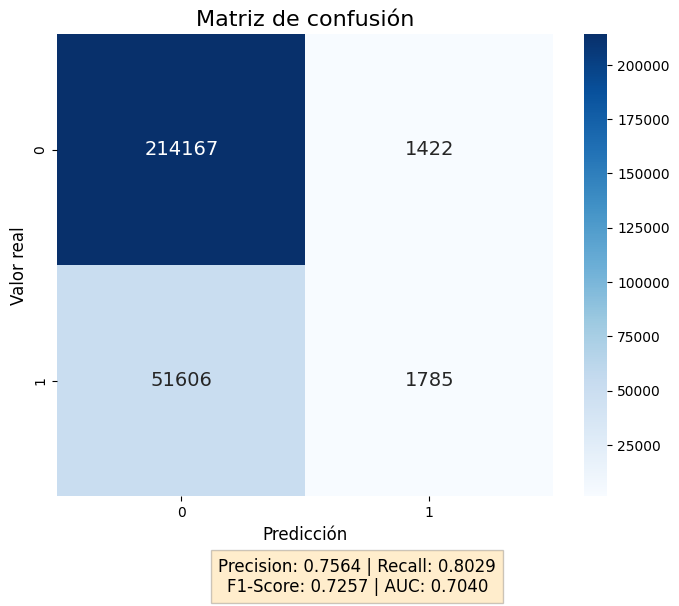

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_confusion_matrix(matrix, precision, recall, f1, auc):
    plt.figure(figsize=(8, 6))
    
    # Creamos el mapa de calor similar a tu imagen
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['0', '1'], yticklabels=['0', '1'],
                annot_kws={"size": 14})
    
    plt.title('Matriz de confusión', fontsize=16)
    plt.xlabel('Predicción', fontsize=12)
    plt.ylabel('Valor real', fontsize=12)
    
    # Añadimos las métricas como texto debajo de la gráfica para referencia
    stats_text = f"Precision: {precision:.4f} | Recall: {recall:.4f}\nF1-Score: {f1:.4f} | AUC: {auc:.4f}"
    plt.figtext(0.5, -0.05, stats_text, ha="center", fontsize=12, 
                bbox={"facecolor":"orange", "alpha":0.2, "pad":5})
    
    plt.show()

# Llamada a la función con tus variables de Spark
plot_confusion_matrix(conf_matrix, precision_spark, recall_spark, f1_spark, auc_final)

Esta matriz de confusión refleja un modelo con un fuerte sesgo hacia la clase mayoritaria (0), donde, a pesar de mostrar métricas generales aparentemente aceptables como un AUC de 0.7040 y un Recall del 80%, existe una deficiencia crítica en la detección de la clase positiva (1). Aunque el modelo identifica correctamente la gran mayoría de los casos negativos (214,167 Verdaderos Negativos), falla masivamente al clasificar 51,606 Falsos Negativos, lo que significa que la gran mayoría de los eventos de interés real pasan desapercibidos. Con apenas 1,785 Verdaderos Positivos, el modelo tiene una sensibilidad real muy baja para la clase 1, sugiriendo que el rendimiento reportado en las etiquetas inferiores está inflado por el desbalance de los datos y que se requiere urgentemente una estrategia de balanceo o un ajuste de umbral para mejorar la capacidad predictiva sobre la clase minoritaria.  

# Comparación entre Random Forest en Scikit-learn y PySpark

In [116]:
import pandas as pd

# Crear tabla comparativa
comparacion = pd.DataFrame({
    "Modelo": ["Scikit-learn", "PySpark"],
    "Precision": [precision, precision_spark],
    "Recall": [recall, recall_spark],
    "F1-Score": [f1, f1_spark],
    "AUC": [roc, auc_final],
    "Tiempo (minutos)": [13.3, 12.15]
})

comparacion

,Modelo,Precision,Recall,F1-Score,AUC,Tiempo (minutos)
0,Scikit-learn,0.770048,0.596197,0.636458,0.697730,13.30
1,PySpark,0.756356,0.802855,0.725730,0.703967,12.15


<Figure size 1000x600 with 0 Axes>

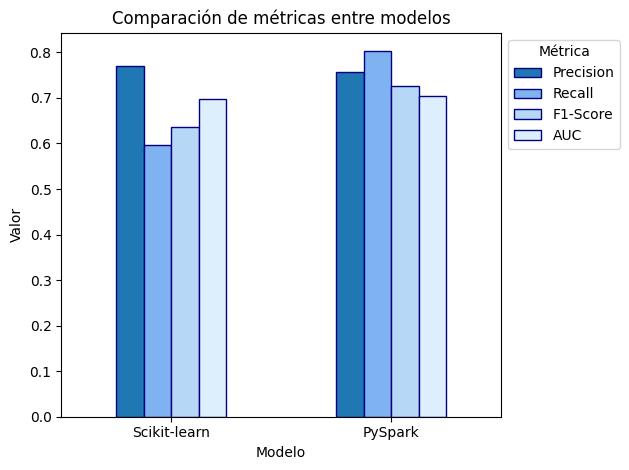

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6)) 

comparacion.set_index("Modelo")[["Precision", "Recall", "F1-Score", "AUC"]].plot(
    kind="bar",
    color=['#1f77b4', '#7fb2f0', '#b6d7f6', '#ddeffc'], 
    edgecolor='navy' 
)

plt.title("Comparación de métricas entre modelos")
plt.ylabel("Valor")
plt.xticks(rotation=0)  

plt.legend(title="Métrica", bbox_to_anchor=(1, 1), loc='upper left') 
plt.tight_layout()  
plt.show()

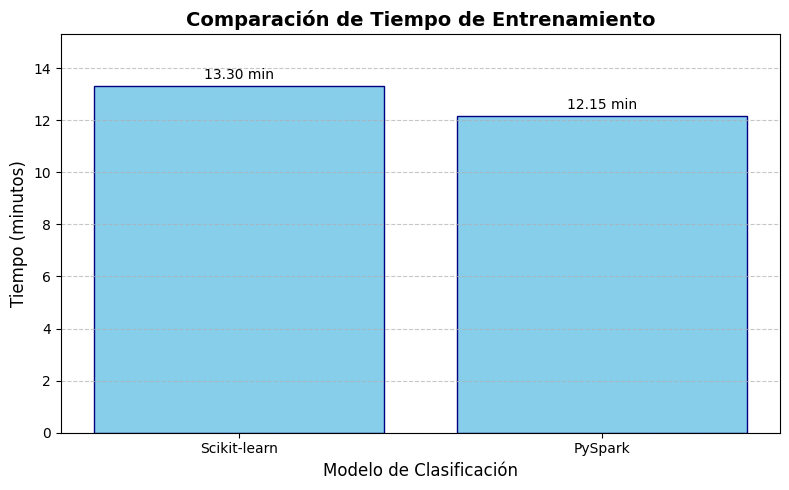

In [ ]:
plt.figure(figsize=(8, 5))

barras = plt.bar(comparacion["Modelo"], comparacion["Tiempo (minutos)"], color='skyblue', edgecolor='navy')

plt.bar_label(barras, padding=3, fmt='%.2f min')

plt.title("Comparación de Tiempo de Entrenamiento", fontsize=14, fontweight='bold')
plt.xlabel("Modelo de Clasificación", fontsize=12)
plt.ylabel("Tiempo (minutos)", fontsize=12)

plt.ylim(0, max(comparacion["Tiempo (minutos)"]) * 1.15)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

A partir de los resultados obtenidos, se evidencia que el modelo implementado en PySpark presenta un mejor desempeño general en comparación con Scikit-learn. En términos de métricas, PySpark logra un mayor recall (0.8029 vs 0.5962), lo cual es especialmente importante en este problema, ya que implica una mejor capacidad para identificar correctamente los casos de default. Asimismo, el AUC también es ligeramente superior en PySpark (0.7040 vs 0.6977), lo que indica una mejor capacidad de discriminación global. Aunque Scikit-learn presenta una precisión ligeramente mayor (0.77 vs 0.7564), esta diferencia es marginal y se ve compensada por el bajo recall, lo que sugiere que el modelo está siendo más conservador al predecir defaults. En consecuencia, el modelo de PySpark ofrece un balance más adecuado entre precisión y recall, reflejado en un mejor desempeño general en problemas desbalanceados.

En cuanto al tiempo de cómputo, PySpark demuestra una ventaja significativa, completando el entrenamiento en aproximadamente 12 minutos, mientras que Scikit-learn requiere aproximadamente 13 minutos. Esto resalta la capacidad de PySpark para manejar grandes volúmenes de datos de manera distribuida, optimizando el uso de recursos y reduciendo los tiempos de procesamiento. Esta diferencia es especialmente relevante considerando el tamaño del dataset (más de un millón de registros), donde Scikit-learn enfrenta limitaciones de memoria y paralelización.

En este contexto, PySpark resulta especialmente útil en escenarios donde se trabaja con grandes volúmenes de datos o cuando se requiere escalar el procesamiento, ya que permite distribuir la carga computacional y evitar problemas de memoria como los observados en Scikit-learn. Por otro lado, Scikit-learn sigue siendo una excelente opción para prototipado rápido, datasets más pequeños y experimentación, gracias a su facilidad de uso y amplia flexibilidad. En conclusión, aunque ambos enfoques son válidos, PySpark se posiciona como la mejor alternativa en este caso debido a su eficiencia computacional y mejor equilibrio en las métricas de desempeño.